# Create Figures for Paper

python 3.14

#### Import packages

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# import matplotlib.patheffects as pe
import matplotlib.colors as mcolors

# import seaborn as sns
import numpy as np
import textwrap
import squarify
import matplotlib.cm as cm

from IPython.core.interactiveshell import InteractiveShell

InteractiveShell.ast_node_interactivity = "all"
pd.set_option("display.max_rows", None)

#### Import dataset

In [3]:
df = pd.read_csv("../raw/databases_rna_sugarcane.csv")
df.head()

,Run,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Library Name,Bytes,Center Name,Consent,...,trait,soil_type,rainfall,soil_fertilized,tissue_ontology,time_ontology,treatment_ontology,trait_ontology,lat_decimal,lon_decimal
0,ERR5881912,RNA-Seq,202,6874016166,PRJEB44480,SAMEA8659526,NaN,1975630395,UNIVERSITY OF QUEENSLAND,public,...,NaN,NaN,7-day flood irrigation schedule,"N 160 kg/ha, p kg/ha, k kg/ha and s 20 kg/ha",PO:0020142,NaN,NaN,NaN,-19.568889,147.325194
1,ERR5880619,RNA-Seq,202,7173776894,PRJEB44480,SAMEA8663682,NaN,2028601309,UNIVERSITY OF QUEENSLAND,public,...,NaN,NaN,7-day flood irrigation schedule,"N 160 kg/ha, p kg/ha, k kg/ha and s 20 kg/ha",PO:0020142,NaN,NaN,NaN,-19.568889,147.325194
2,ERR5881901,RNA-Seq,202,6590308782,PRJEB44480,SAMEA8663689,NaN,1873691431,UNIVERSITY OF QUEENSLAND,public,...,NaN,NaN,7-day flood irrigation schedule,"N 160 kg/ha, p kg/ha, k kg/ha and s 20 kg/ha",PO:0020142,NaN,NaN,NaN,-19.568889,147.325194
3,ERR5881831,RNA-Seq,202,6378393208,PRJEB44480,SAMEA8663694,NaN,1801972540,UNIVERSITY OF QUEENSLAND,public,...,NaN,NaN,7-day flood irrigation schedule,"N 160 kg/ha, p kg/ha, k kg/ha and s 20 kg/ha",PO:0020142,NaN,NaN,NaN,-19.568889,147.325194
4,ERR5881820,RNA-Seq,202,7570365716,PRJEB44480,SAMEA8659525,NaN,2148351779,UNIVERSITY OF QUEENSLAND,public,...,NaN,NaN,7-day flood irrigation schedule,"N 160 kg/ha, p kg/ha, k kg/ha and s 20 kg/ha",PO:0020142,NaN,NaN,NaN,-19.568889,147.325194


# Country plot

In [9]:
# Count the number of occurrences of each country
country_counts = df["country"].value_counts().reset_index()
country_counts.columns = ["Country", "count"]

# Load the world map from GeoPandas datasets
url = (
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)
world = gpd.read_file(url)

# Remove Antarctica
world = world[world["NAME"] != "Antarctica"]

In [10]:
# Replace 'USA' with 'United States of America' in country_counts
country_counts["Country"] = country_counts["Country"].replace(
    "USA", "United States of America"
)
country_counts.head()

,Country,count
0,China,1356
1,Australia,903
2,Brazil,786
3,United States of America,123
4,India,85


In [11]:
# Merge the world GeoDataFrame with the country counts DataFrame
world_data = world.merge(country_counts, how="left", left_on="NAME", right_on="Country")

# Project the world data to Robinson projection for better visualization
world_data = world_data.to_crs("+proj=robin")

<Axes: >

<Axes: >

(np.float64(-18491143.68863403),
 np.float64(18491143.68863403),
 np.float64(-6612227.92314729),
 np.float64(9055157.537062025))

Text(39.120000000000005, 0, '12')

Text(43.120000000000005, 1, '16')

...

Text(930.12, 6, '903')

Text(1383.12, 7, '1356')

[]

[Text(0, 0, 'Thailand'),
 Text(0, 1, 'Mexico'),
 Text(0, 2, 'South Africa'),
 Text(0, 3, 'India'),
 Text(0, 4, 'United States of America'),
 Text(0, 5, 'Brazil'),
 Text(0, 6, 'Australia'),
 Text(0, 7, 'China')]

Text(0.5, 1.0, 'Runs in Each Country')

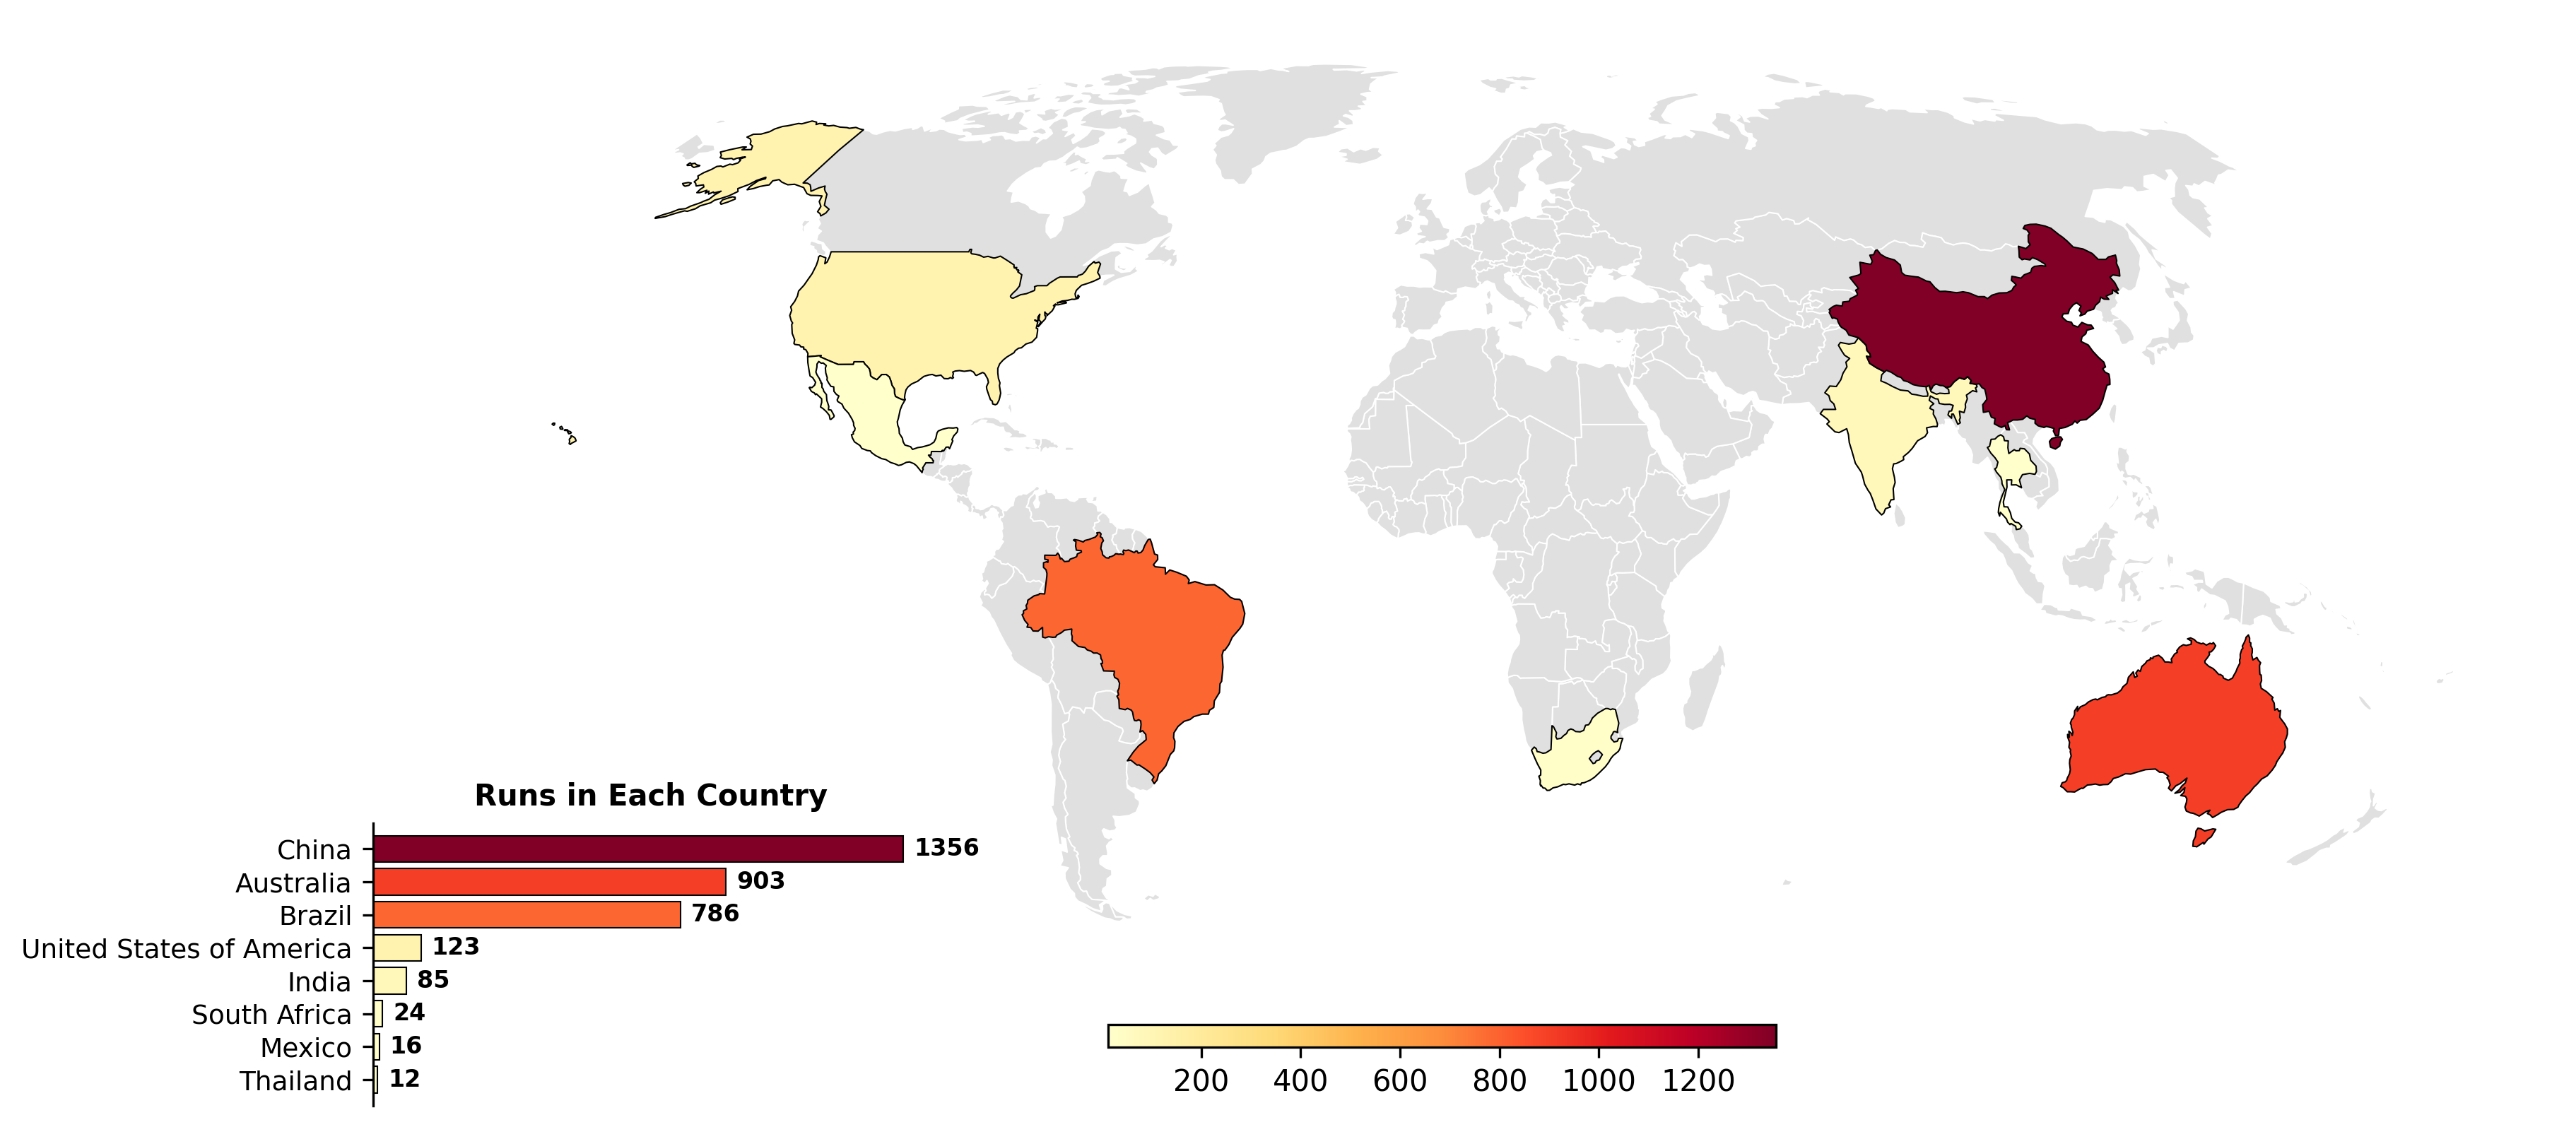

In [7]:
# Configure plot aesthetics for better readability in articles
fig, ax = plt.subplots(1, 1, figsize=(12, 6), dpi=300)

# Plot the base map with neutral colors for countries without data
world_data.plot(ax=ax, color="#e0e0e0", edgecolor="white", linewidth=0.5)

# Plot the countries with data using a color map that is friendly for colorblind readers
data_countries = world_data.dropna(subset=["count"])
data_countries.plot(
    column="count",
    ax=ax,
    cmap="YlOrRd",  # Or 'viridis' YlOrRd
    legend=True,
    edgecolor="black",  # Slightly darker border for countries with data
    linewidth=0.5,
    legend_kwds={
        # 'label': "Runs in Each Country",
        "orientation": "horizontal",
        "shrink": 0.3,  # Size of the legend bar
        "pad": 0.05,  # Distance between the map and the legend
        "aspect": 30,  # Aspect ratio of the legend bar
    },
)

# Remove axes (latitude and longitude) for a clean look
ax.axis("off")

# Inset axes
data_countries_sorted = data_countries.sort_values(by="count", ascending=True)

# Position and size of the inset bar plot (x, y, width, height)
ax_bar = ax.inset_axes([0.02, -0.15, 0.25, 0.30])

norm = mcolors.Normalize(
    vmin=data_countries["count"].min(), vmax=data_countries["count"].max()
)
cmap = plt.get_cmap("YlOrRd")
bar_colors = [cmap(norm(valor)) for valor in data_countries_sorted["count"]]

# Clean data
country_names = data_countries_sorted["NAME"].astype(str).tolist()
values = data_countries_sorted["count"].to_numpy()

# Using numpy create a range of positions for the bars
positions = np.arange(len(country_names))

# Bar plot
bars = ax_bar.barh(
    y=positions, width=values, color=bar_colors, edgecolor="black", linewidth=0.5
)

# Include the values at the end of each bar
for index, value in enumerate(values):
    ax_bar.text(
        value + (max(values) * 0.02),  # x position (a little to the right of the bar)
        index,  # y position (centered on the bar)
        str(int(value)),  # text to display
        va="center",  # vertical alignment centered
        fontsize=8,
        fontweight="bold",
    )

# Remove axes for the inset plot
ax_bar.set_xticks([])
ax_bar.spines["bottom"].set_visible(False)

# Change y-axis labels to country names
ax_bar.set_yticks(positions)
ax_bar.set_yticklabels(country_names)

# Clean formatting for the inset bar plot
ax_bar.set_title("Runs in Each Country", fontsize=10, fontweight="bold")
ax_bar.tick_params(axis="y", labelsize=9)
ax_bar.tick_params(axis="x", labelsize=8)

# Pretty formatting for the inset bar plot
ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)

# Optional
# ax_bar.set_facecolor('#f8f9fa')
# ax_bar.patch.set_alpha(0.8)


# Title
# ax.set_title("Global Distribution of Occurrences", fontsize=14, pad=15)

# Adjust layout to avoid cutting off elements
plt.tight_layout()

# Save the figure in high resolution in TIFF or PDF formats
# plt.savefig("mapa_coropletico_alta_res.pdf", bbox_inches='tight', dpi=300)
plt.savefig("map.png", bbox_inches="tight", dpi=300)

plt.show()

Text(39.120000000000005, 0, '12')

Text(43.120000000000005, 1, '16')

Text(51.120000000000005, 2, '24')

Text(112.12, 3, '85')

Text(150.12, 4, '123')

Text(813.12, 5, '786')

Text(930.12, 6, '903')

Text(1383.12, 7, '1356')

[Text(0, 0, 'Thailand'),
 Text(0, 1, 'Mexico'),
 Text(0, 2, 'South Africa'),
 Text(0, 3, 'India'),
 Text(0, 4, 'United States of America'),
 Text(0, 5, 'Brazil'),
 Text(0, 6, 'Australia'),
 Text(0, 7, 'China')]

Text(0.5, 1.0, 'Runs in Each Country')

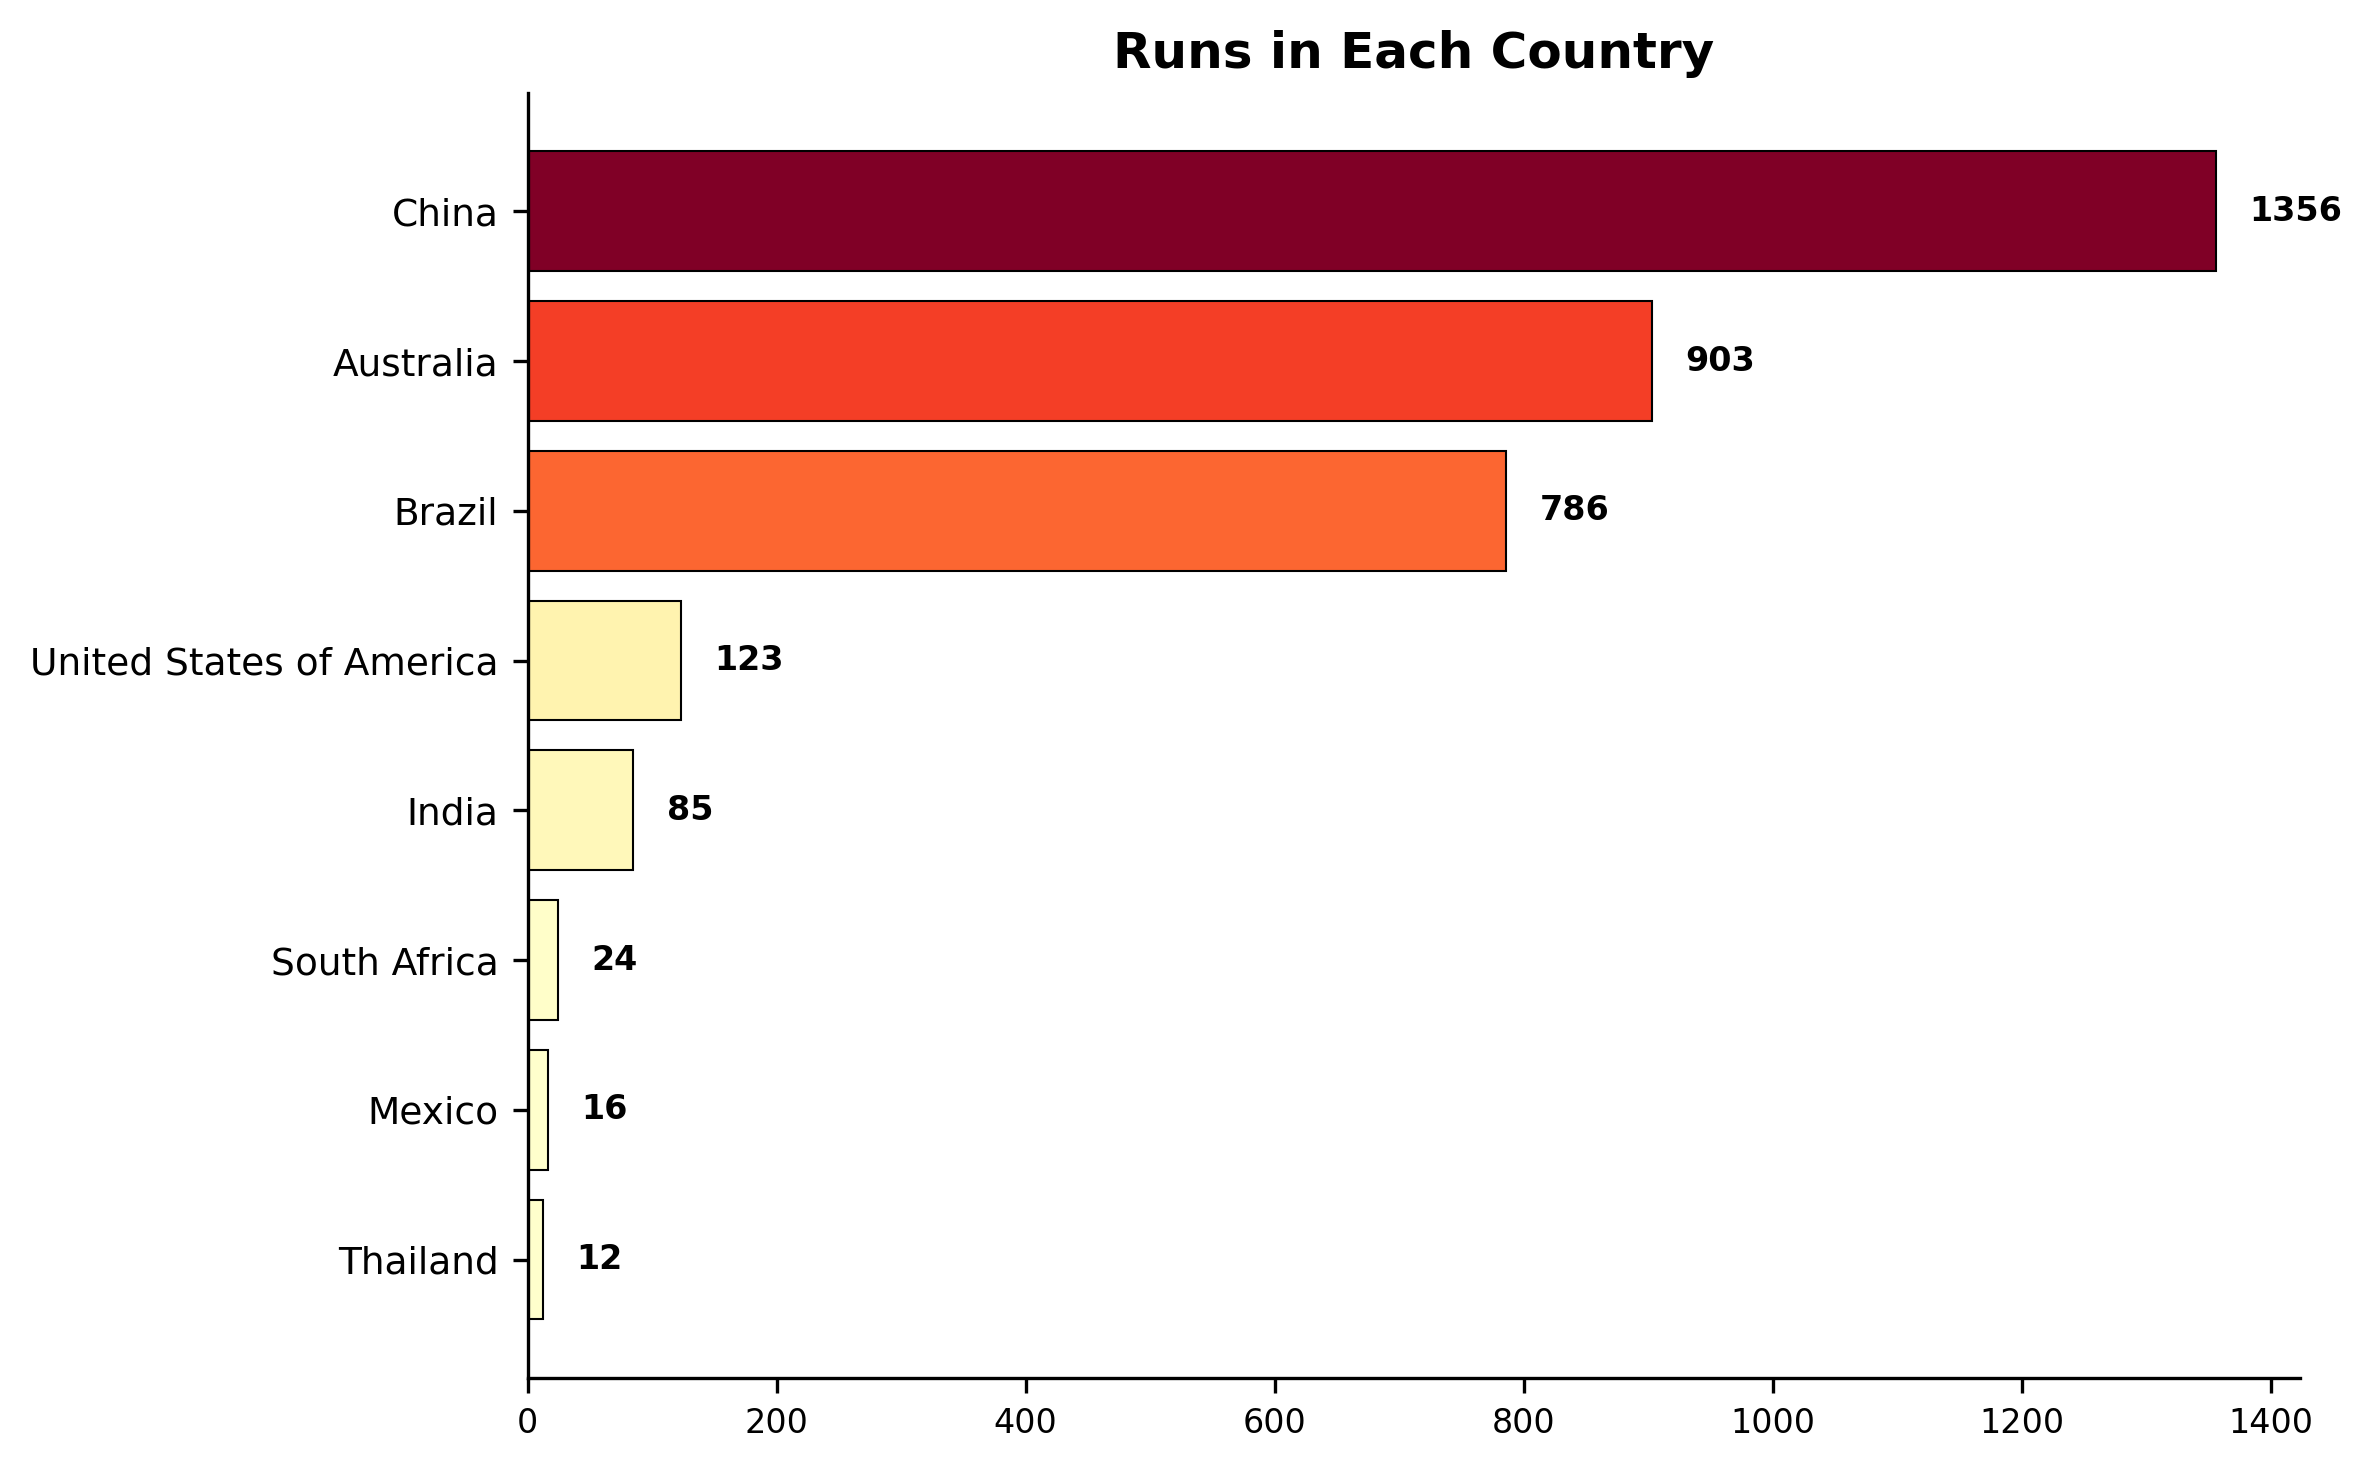

In [15]:
# Plot the countries with data using a color map that is friendly for colorblind readers
data_countries = world_data.dropna(subset=["count"])

# Sort the data by count for better visualization in the bar plot
data_countries_sorted = data_countries.sort_values(by="count", ascending=True)

# Color normalization for the bar plot
norm = mcolors.Normalize(
    vmin=data_countries["count"].min(),
    vmax=data_countries["count"].max()
)
cmap = plt.get_cmap("YlOrRd")
bar_colors = [cmap(norm(valor)) for valor in data_countries_sorted["count"]]

# Data for the bar plot
country_names = data_countries_sorted["NAME"].astype(str).tolist()
values = data_countries_sorted["count"].to_numpy()
positions = np.arange(len(country_names))

# Figure and axis for the bar plot
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

# Barplot horizontal
bars = ax.barh(
    y=positions,
    width=values,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.5
)

# Values at the end of the bars
for index, value in enumerate(values):
    ax.text(
        value + (max(values) * 0.02),
        index,
        str(int(value)),
        va="center",
        fontsize=8,
        fontweight="bold",
    )

# Remove axes for the bar plot
ax.set_yticks(positions)
ax.set_yticklabels(country_names)
ax.set_title("Runs in Each Country", fontsize=12, fontweight="bold")

ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", labelsize=8)

# Aesthetic adjustments for the bar plot
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save the bar plot in high resolution in TIFF or PDF formats
plt.savefig("../figures/barplot.png", bbox_inches="tight", dpi=300)

plt.show()

# Growth condition

In [9]:
# Calculate counts and percentages
df_unique_gr = df.drop_duplicates(subset=["BioProject", "growth_conditions"]).copy()

# Calculate counts and percentages for growth conditions
gc_counts = df_unique_gr["growth_conditions"].value_counts()
total_samples = len(df_unique_gr)
percentages = (gc_counts / total_samples) * 100

Text(0.0, 60.18, 'N=59\n(37.3%)')

Text(1.0, 52.18, 'N=51\n(32.3%)')

Text(2.0, 2.1799999999999997, 'N=1\n(0.6%)')

Text(0, 0.5, 'Number of Occurrences')

Text(0.5, 0, 'Growth Conditions')

(0.0, 67.85)

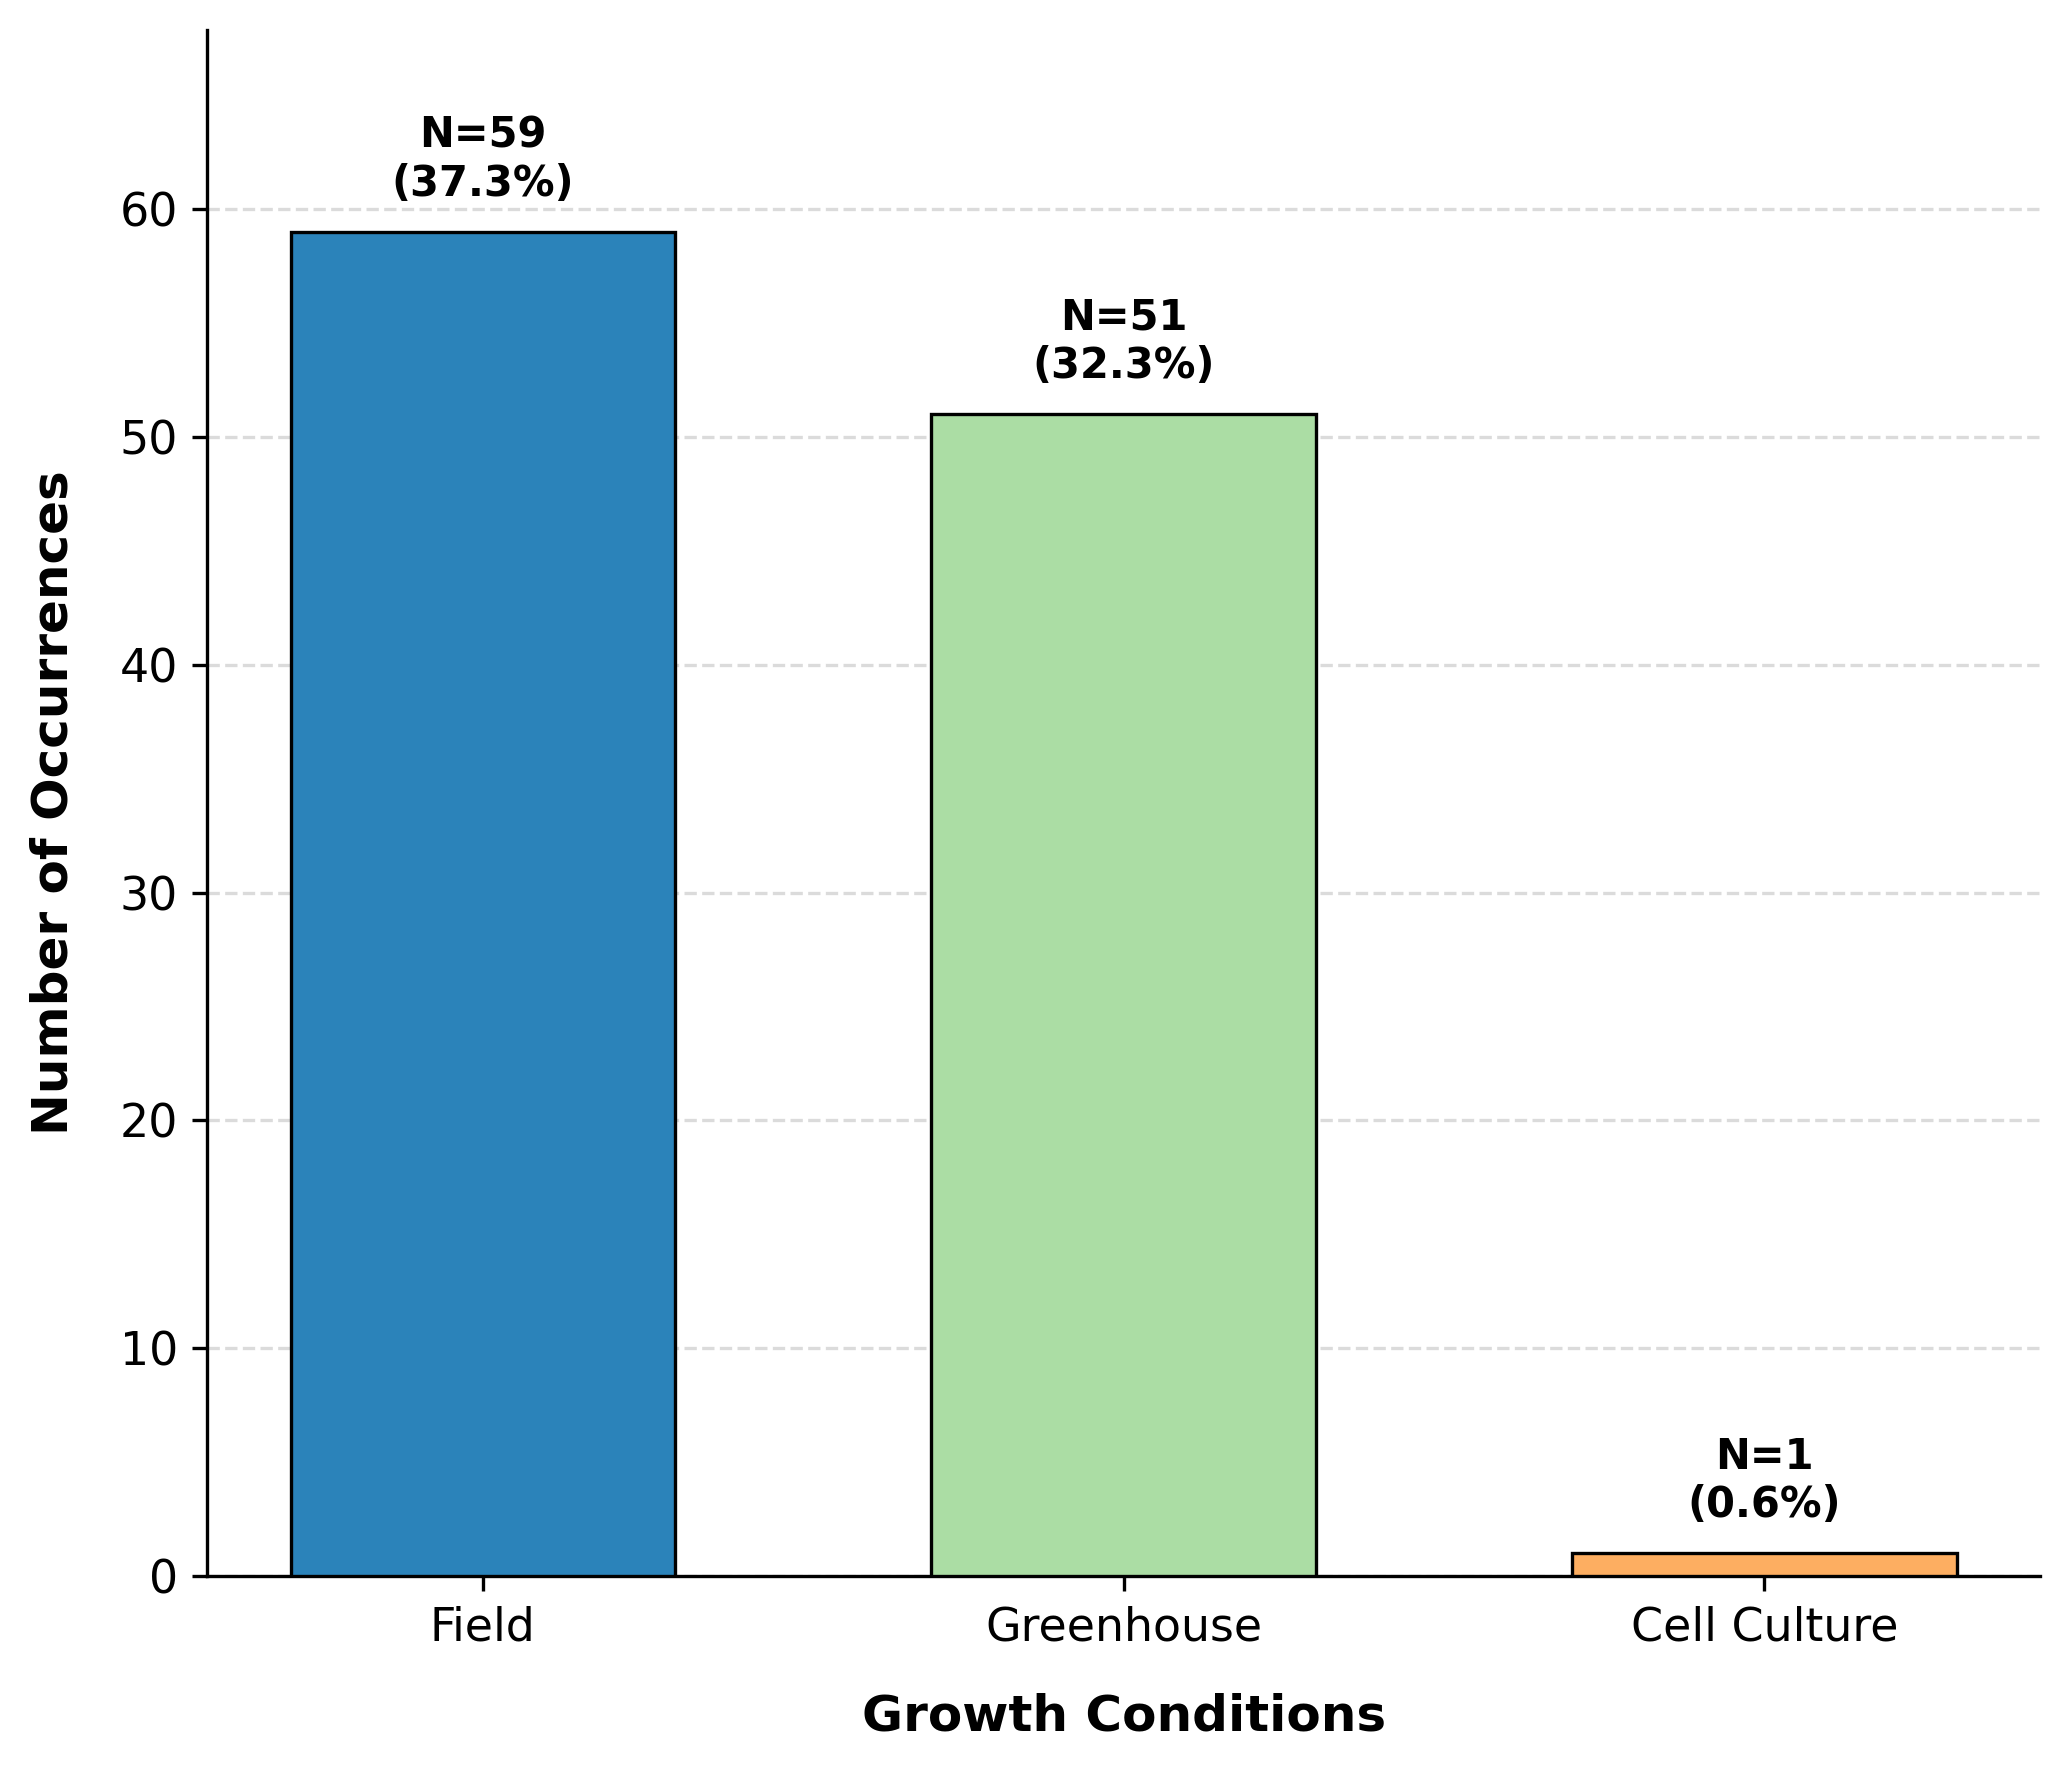

In [10]:
fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

# Define a clean, colorblind-friendly color palette for the 3 categories
# Colors: Dark Blue, Light Blue, Orange/Gold
colors = ["#2b83ba", "#abdda4", "#fdae61"]

# Create the bar chart on the specified 'ax'
# 'zorder=3' ensures bars are drawn on top of the grid lines
bars = ax.bar(
    gc_counts.index,
    gc_counts.values,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    width=0.6,
    zorder=3,
)

# Add exact N and % on top of each bar
for bar, count, pct in zip(bars, gc_counts.values, percentages.values):
    height = bar.get_height()
    # Adding the text slightly above the bar (pad = 2% of the max height)
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + (gc_counts.max() * 0.02),
        f"N={count}\n({pct:.1f}%)",  # Format: N=value (xx.x%)
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="black",
    )

# Clean up the axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add a subtle horizontal grid for better readability of the Y-axis values
ax.yaxis.grid(True, linestyle="--", color="#cccccc", alpha=0.7, zorder=0)
ax.set_axisbelow(True)  # Ensure grid is strictly behind the bars

# Set labels and title
ax.set_ylabel("Number of Occurrences", fontsize=12, fontweight="bold", labelpad=10)
ax.set_xlabel("Growth Conditions", fontsize=12, fontweight="bold", labelpad=10)

# Adjust tick label sizes
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)

# Ensure Y-axis has enough headroom for the text annotations (expand top limit by 15%)
ax.set_ylim(0, gc_counts.max() * 1.15)

# Adjust layout
plt.tight_layout()

plt.show()

# RunCount

Text(0.5, 0, 'Number of Runs per BioProject (Log Scale)')

Text(0, 0.5, 'Frequency (Number of BioProjects)')

Text(0.95, 0.95, 'Total BioProjects: 158\nMedian Runs/Project: 10\nMean Runs/Project: 21.4')

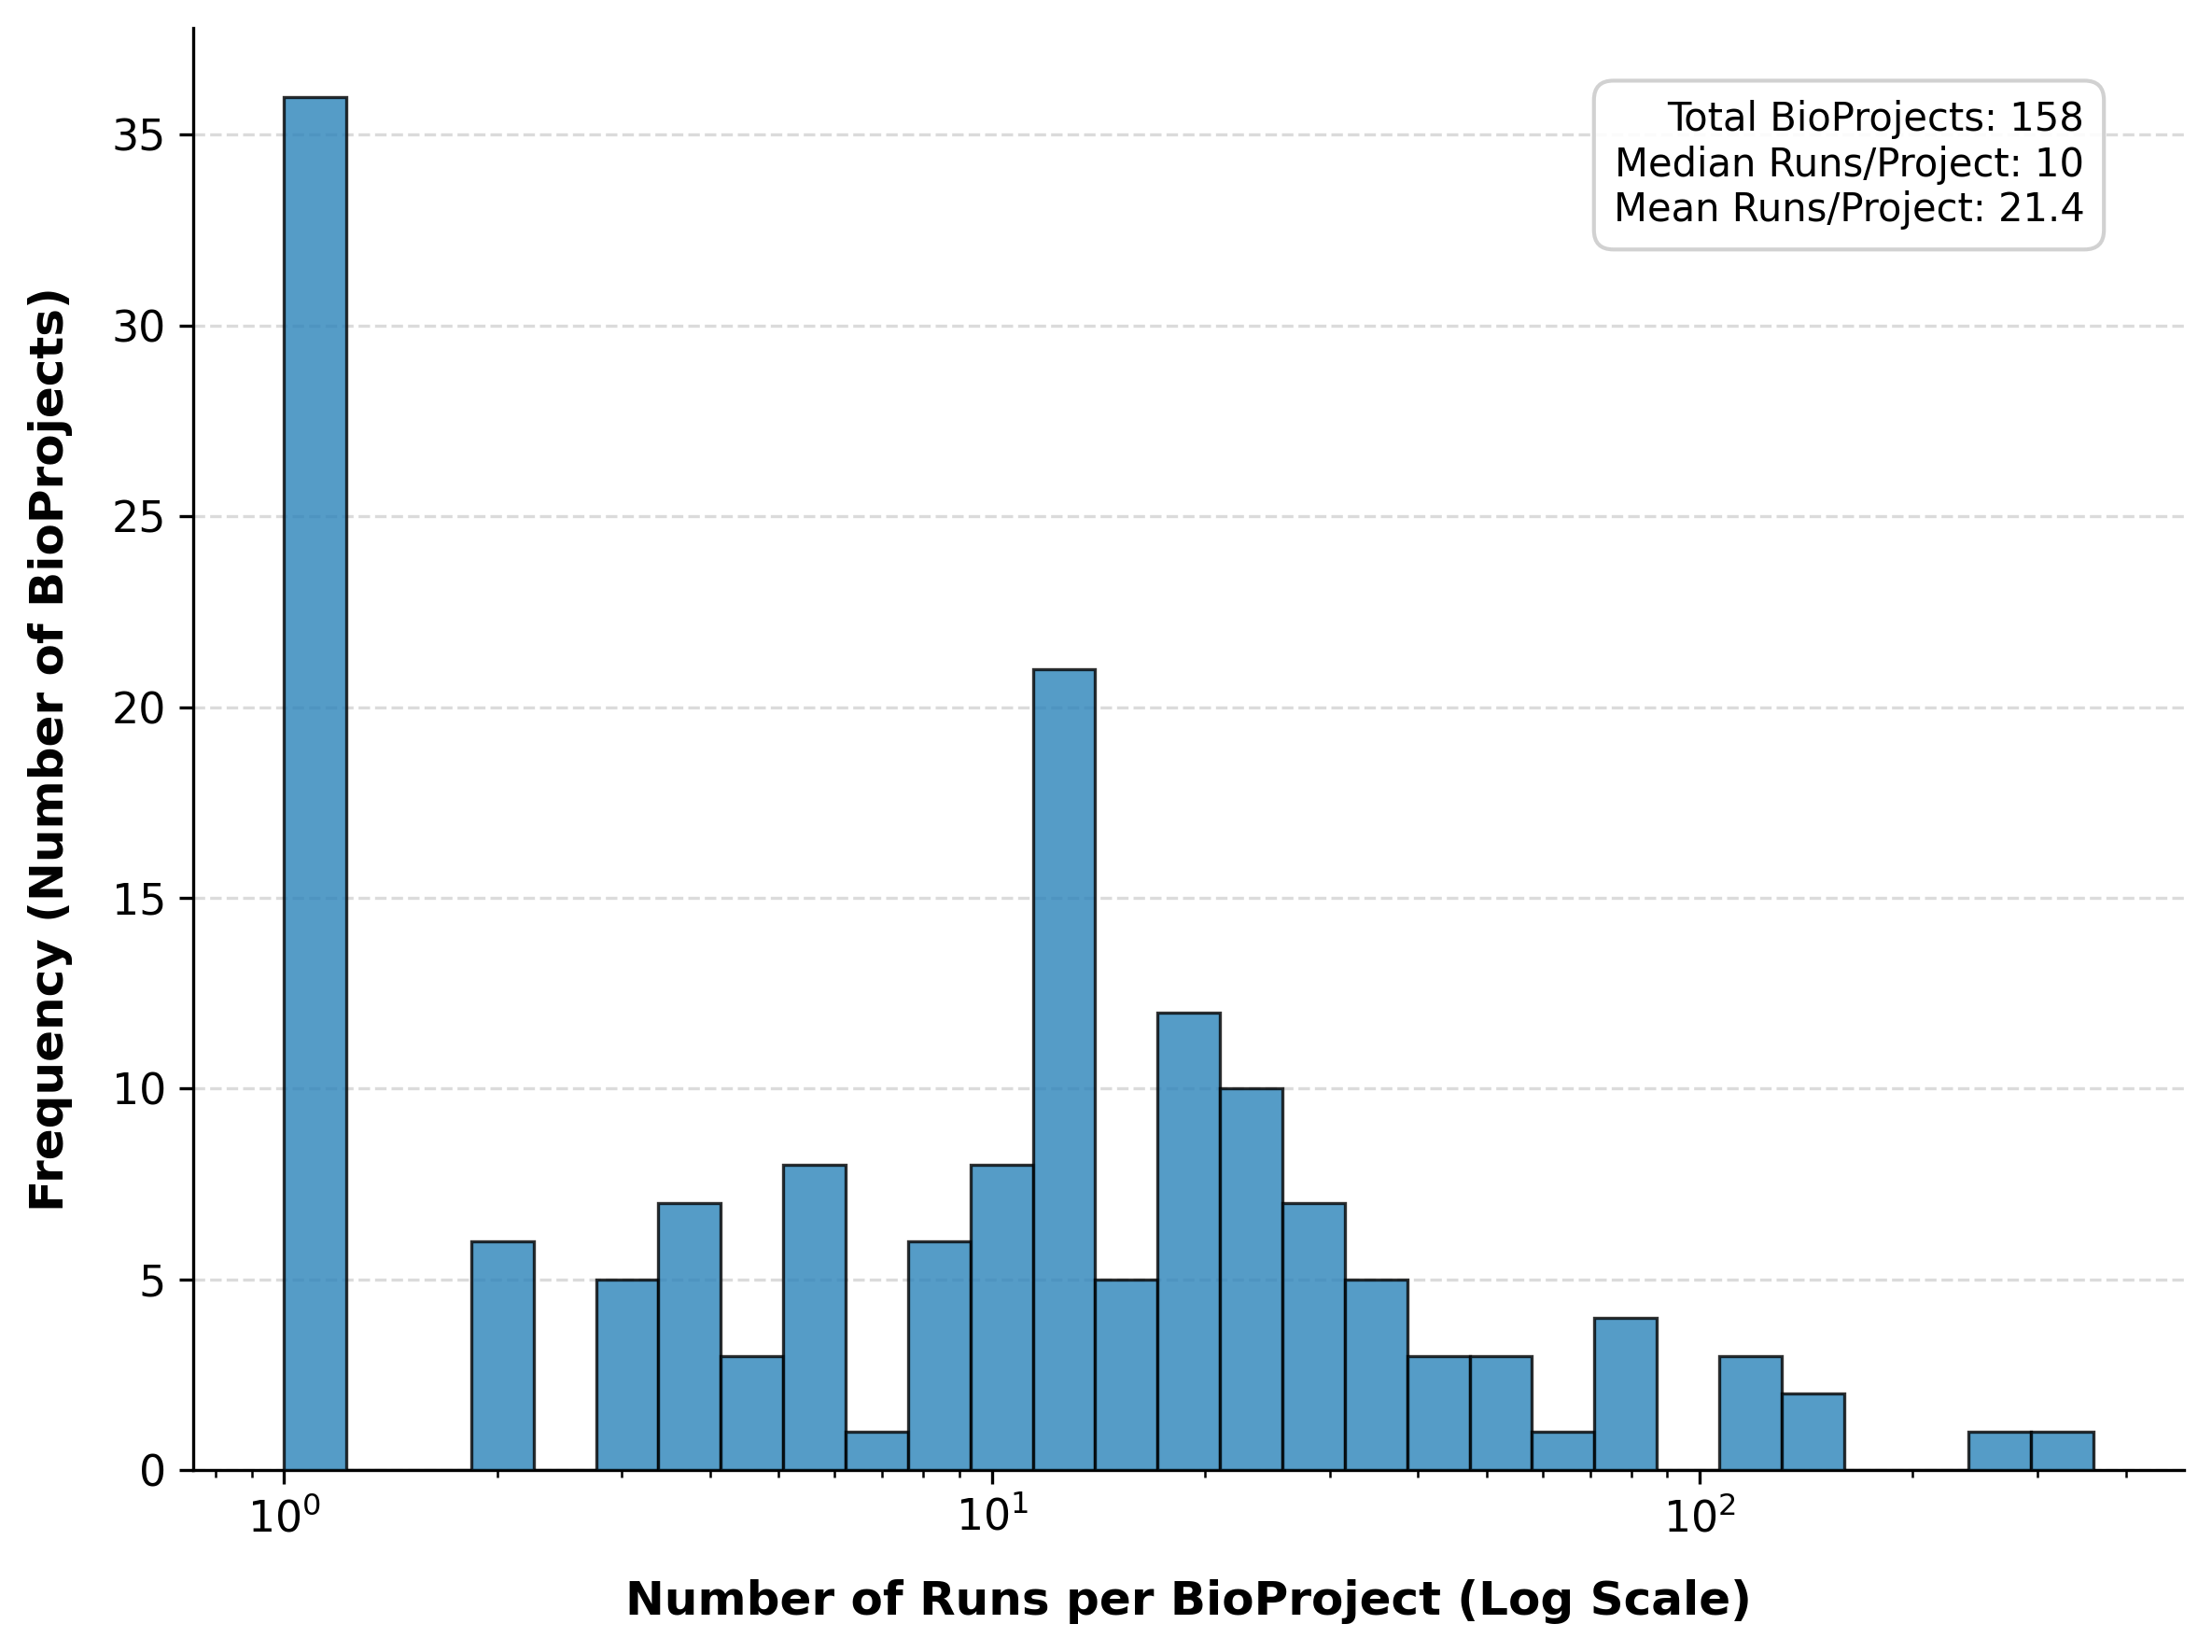

In [11]:
# Toggle for Logarithmic Scale
USE_LOG_SCALE = True
# Deduplicate the data
# We only want one row per BioProject to understand project size distribution
df_projects = df.drop_duplicates(subset=["BioProject"]).copy()
run_counts = df_projects["RunCount"]

# Subplot Setup & Plotting
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# Conditional logic for Bins and Scale based on the toggle
if USE_LOG_SCALE:
    # Log scale configuration
    min_val = max(1, run_counts.min())  # Avoid log(0)
    max_val = run_counts.max()
    # Create bins that grow logarithmically
    dynamic_bins = np.logspace(
        np.log10(min_val), np.log10(max_val), num=30
    )  # Use logspace for logarithmic bins
    ax.set_xscale("log")
    x_label = "Number of Runs per BioProject (Log Scale)"
else:
    # Linear scale configuration
    # Create 30 evenly spaced bins from min to max
    dynamic_bins = np.linspace(run_counts.min(), run_counts.max(), num=30)
    # The X-axis defaults to linear
    x_label = "Number of Runs per BioProject (Linear Scale)"

# Create the histogram
counts, bins, patches = ax.hist(
    run_counts,
    bins=dynamic_bins,
    color="#2b83ba",  # colorblind-friendly blue
    edgecolor="black",  # Distinct borders
    linewidth=0.8,
    alpha=0.8,  # Slight transparency
    zorder=3,  # Keep bars above the grid
)

# Clean up spines (remove top and right borders)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add a subtle grid for the Y-axis
ax.yaxis.grid(True, linestyle="--", color="#cccccc", alpha=0.7, zorder=0)
ax.set_axisbelow(True)  # Ensure grid is behind the bars

# Set dynamic labels based on the scale chosen
ax.set_xlabel(x_label, fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylabel(
    "Frequency (Number of BioProjects)", fontsize=12, fontweight="bold", labelpad=10
)

# Tick formatting
ax.tick_params(axis="both", which="major", labelsize=11)

# Add a text box with summary statistics
median_runs = run_counts.median()
mean_runs = run_counts.mean()
total_projects = len(run_counts)

stats_text = (
    f"Total BioProjects: {total_projects}\n"
    f"Median Runs/Project: {median_runs:.0f}\n"
    f"Mean Runs/Project: {mean_runs:.1f}"
)

# Place text box in the upper right corner
ax.text(
    0.95,
    0.95,
    stats_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(
        boxstyle="round,pad=0.5", facecolor="white", alpha=0.9, edgecolor="#cccccc"
    ),
)

plt.tight_layout()

plt.show()

# Tissue

In [14]:
# Count treatment values
treatment_counts = df["tissue_ontology"].value_counts()
treatment_counts

tissue_ontology
PO:0025034    1478
PO:0020142     802
PO:0009047     426
PO:0009005     277
PO:0000055      79
PO:0004709      70
PO:0009046      37
PO:0009013      32
PO:0020121      30
PO:0020040      24
PO:0020137      12
PO:0020141       9
PO:0025223       9
PO:0025178       8
PO:0009011       6
PO:0006109       2
Name: count, dtype: int64

In [15]:
# Create a mapping from PO IDs to human-readable names
# Used the Plant Ontology (PO) database to find the corresponding names for each PO ID
# https://bioportal.bioontology.org/ontologies/PO
po2name = {
    "PO:0025034": "Leaf",
    "PO:0020142": "Stem Internode",
    "PO:0009047": "Stem",
    "PO:0009005": "Root",
    "PO:0000055": "Bud",
    "PO:0004709": "Auxiliary Bud",
    "PO:0009046": "Flower",
    "PO:0009013": "Meristem",
    "PO:0020121": "Lateral Root",
    "PO:0020040": "Leaf Base",
    "PO:0020137": "Leaf Apex",
    "PO:0020141": "Stem Node",
    "PO:0025223": "Vegetative Shoot Apex",
    "PO:0025178": "Stem Epidermis",
    "PO:0009011": "Plant Structure",
    "PO:0006109": "Pith",
}

<Axes: >

(np.float64(0.0), np.float64(100.0), np.float64(0.0), np.float64(100.0))

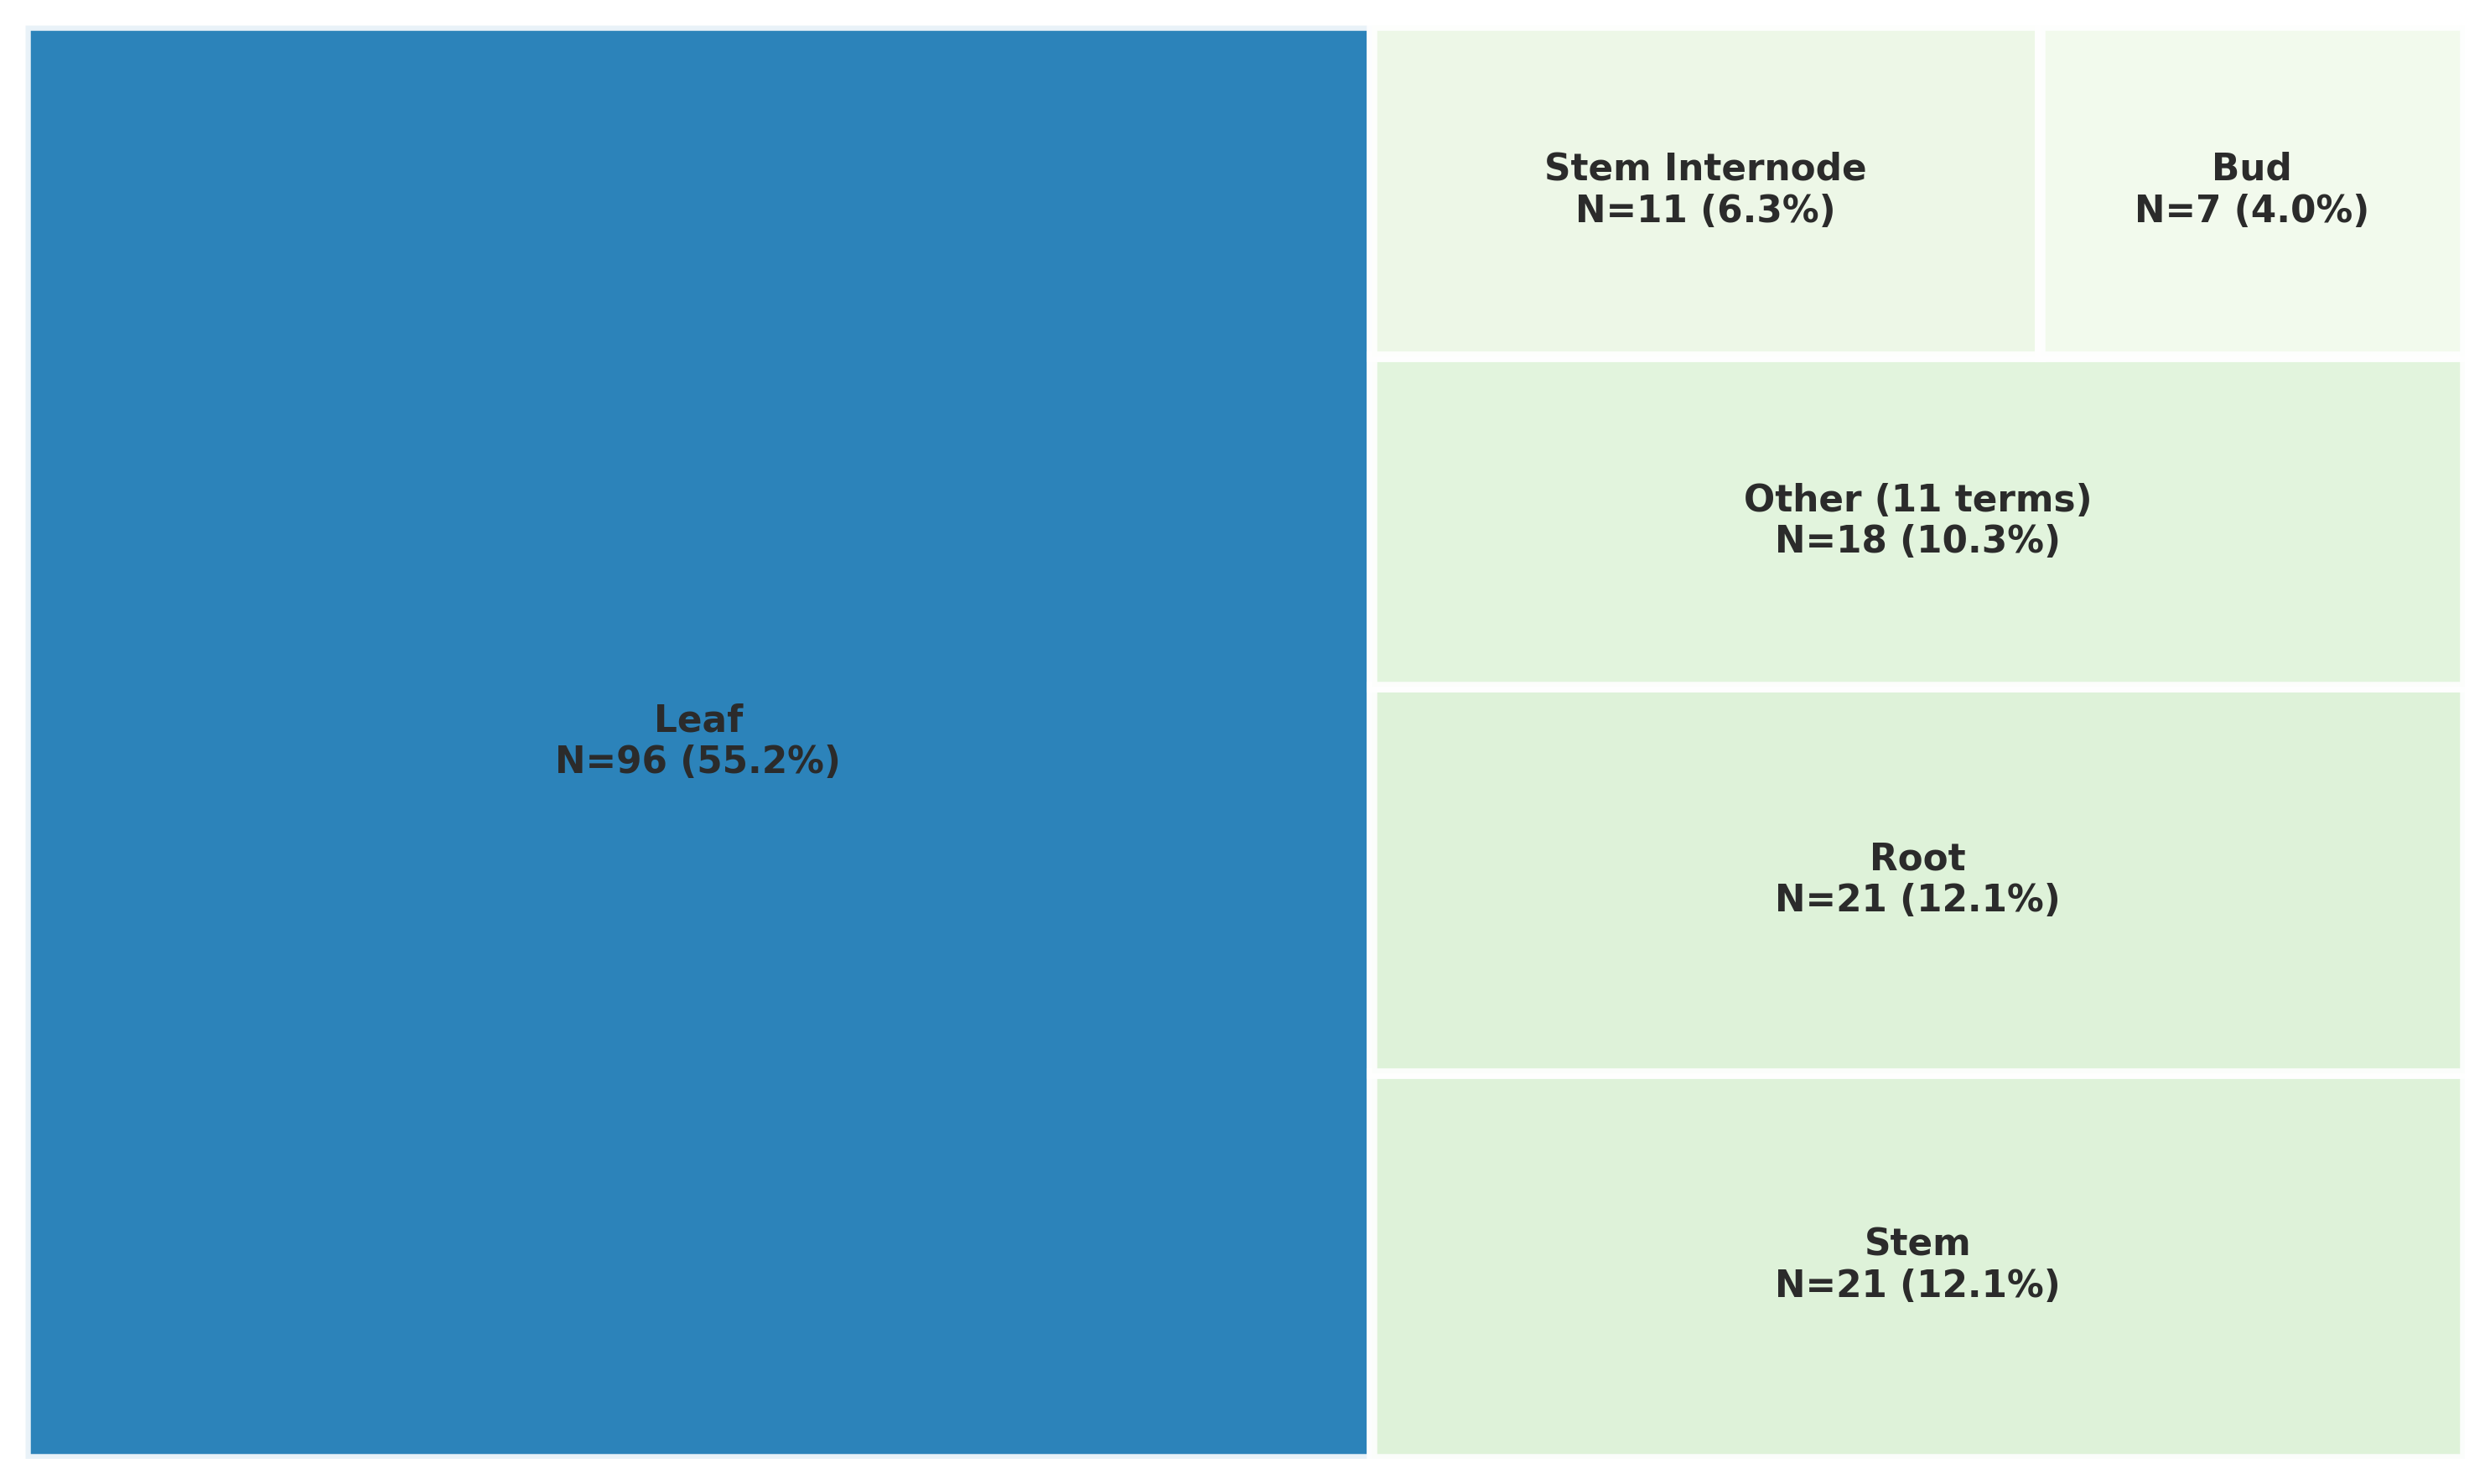

In [16]:
# Map the Plant Ontology IDs to human-readable names
df["ontology_term"] = df["tissue_ontology"].map(po2name)

# Deduplicate: Count each tissue only ONCE per BioProject
df_unique = df.drop_duplicates(subset=["BioProject", "ontology_term"]).copy()

# Calculate frequencies
term_counts = df_unique["ontology_term"].value_counts().reset_index()
term_counts.columns = ["ontology_term", "count"]

# Grouping minor categories into "Other" if they are below a certain percentage threshold
# Avoid tailoring the plot to a long tail of very small categories that would be hard to read and interpret in a TreeMap
total_count = term_counts["count"].sum()
THRESHOLD_PERCENT = 2.0

# Calculate percentages for all terms to enrich our labels later
term_counts["percentage"] = (term_counts["count"] / total_count) * 100

# Separate major categories and minor categories based on the threshold
major_terms = term_counts[term_counts["percentage"] >= THRESHOLD_PERCENT].copy()
minor_terms = term_counts[term_counts["percentage"] < THRESHOLD_PERCENT].copy()

# If there are minor categories, aggregate them into an "Other" category
if not minor_terms.empty:
    other_count = minor_terms["count"].sum()
    other_percentage = minor_terms["percentage"].sum()
    num_minor_categories = len(minor_terms)

    # Create the aggregated row
    other_row = pd.DataFrame(
        {
            "ontology_term": [f"Other ({num_minor_categories} terms)"],
            "count": [other_count],
            "percentage": [other_percentage],
        }
    )

    # Combine major terms with the new aggregated row
    term_counts_clean = pd.concat([major_terms, other_row], ignore_index=True)
else:
    term_counts_clean = major_terms

# Sort so the largest boxes are positioned first (usually top-left)
term_counts_clean = term_counts_clean.sort_values(by="count", ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Green-Blue colormap colorblind-friendly
cmap = plt.colormaps.get_cmap("GnBu")

# Constrain the normalization range so the darkest color isn't purely dark.
# This ensures our dark gray text remains highly readable on all boxes.
norm = mcolors.Normalize(
    vmin=term_counts_clean["count"].min() * 0.5,
    vmax=term_counts_clean["count"].max() * 1.2,
)
color_list = [cmap(norm(value)) for value in term_counts_clean["count"]]

# Add percentage to the labels for immediate context
labels = [
    f"{row['ontology_term']}\nN={row['count']} ({row['percentage']:.1f}%)"
    for _, row in term_counts_clean.iterrows()
]

# Plot the TreeMap
squarify.plot(
    sizes=term_counts_clean["count"],
    label=labels,
    color=color_list,
    alpha=0.9,  # Slightly less transparent for richer, solid colors
    edgecolor="white",  # Crisp white borders separate the blocks clearly
    linewidth=3,  # Thicker lines create a modern tile effect
    text_kwargs={
        "fontsize": 10.5,
        "fontweight": "bold",
        "color": "#2b2b2b",  # Soft dark gray is more elegant and easier to read than pure black
        "wrap": True,
    },
    ax=ax,
)

# Remove axes for a clean, minimalist look
ax.axis("off")

plt.tight_layout()

plt.show()

# Treatment

In [18]:
# count treatment_ontology counts
treatment_counts = df["treatment_ontology"].str.strip().value_counts()
treatment_counts

treatment_ontology
PECO:0001062                 228
PECO:0007404                 197
PECO:0007241                 103
PECO:0007357                  76
PECO:0007189                  74
PECO:0007191                  52
PECO:0007174                  15
PECO:0007357,PECO:0007404     13
PECO:0007333                  12
PECO:0007050                  12
PECO:0007078                  12
PECO:0007189,PECO:0007165      9
PECO:0007189,PECO:0007404      5
PECO:0007185                   4
PECO:0001037                   2
PECO:0007173                   1
Name: count, dtype: int64

In [19]:
# Create a mapping from PECO IDs to human-readable names
# Used the Plant Experimental Conditions Ontology (PECO) database to find the corresponding names for each PECO ID
# https://bioportal.bioontology.org/ontologies/PECO
peco2name = {
    "PECO:0001062": "Control",
    " PECO:0001062": "Control",
    "PECO:0007404": "Drought",
    "PECO:0007241": "Plant Nutrient",
    "PECO:0007357": "Biotic Plant",
    "PECO:0007189": "Chemical",
    "PECO:0007191": "Abiotic Plant",
    "PECO:0007174": "Cold Temperature",
    "PECO:0007357,PECO:0007404": "Biotic + Drought",
    "PECO:0007333": "Insect Plant",
    "PECO:0007050": "Soil Texture",
    "PECO:0007078": "Light Quantity",
    "PECO:0007189,PECO:0007165": "Chemical + Plant Growth Hormone",
    "PECO:0007189,PECO:0007404": "Chemical + Drought",
    "PECO:0007185": "Salt",
    "PECO:0001037": "Oxidative Stress",
    "PECO:0007173": "High Temperature",
}

<Axes: >

(np.float64(0.0), np.float64(100.0), np.float64(0.0), np.float64(100.0))

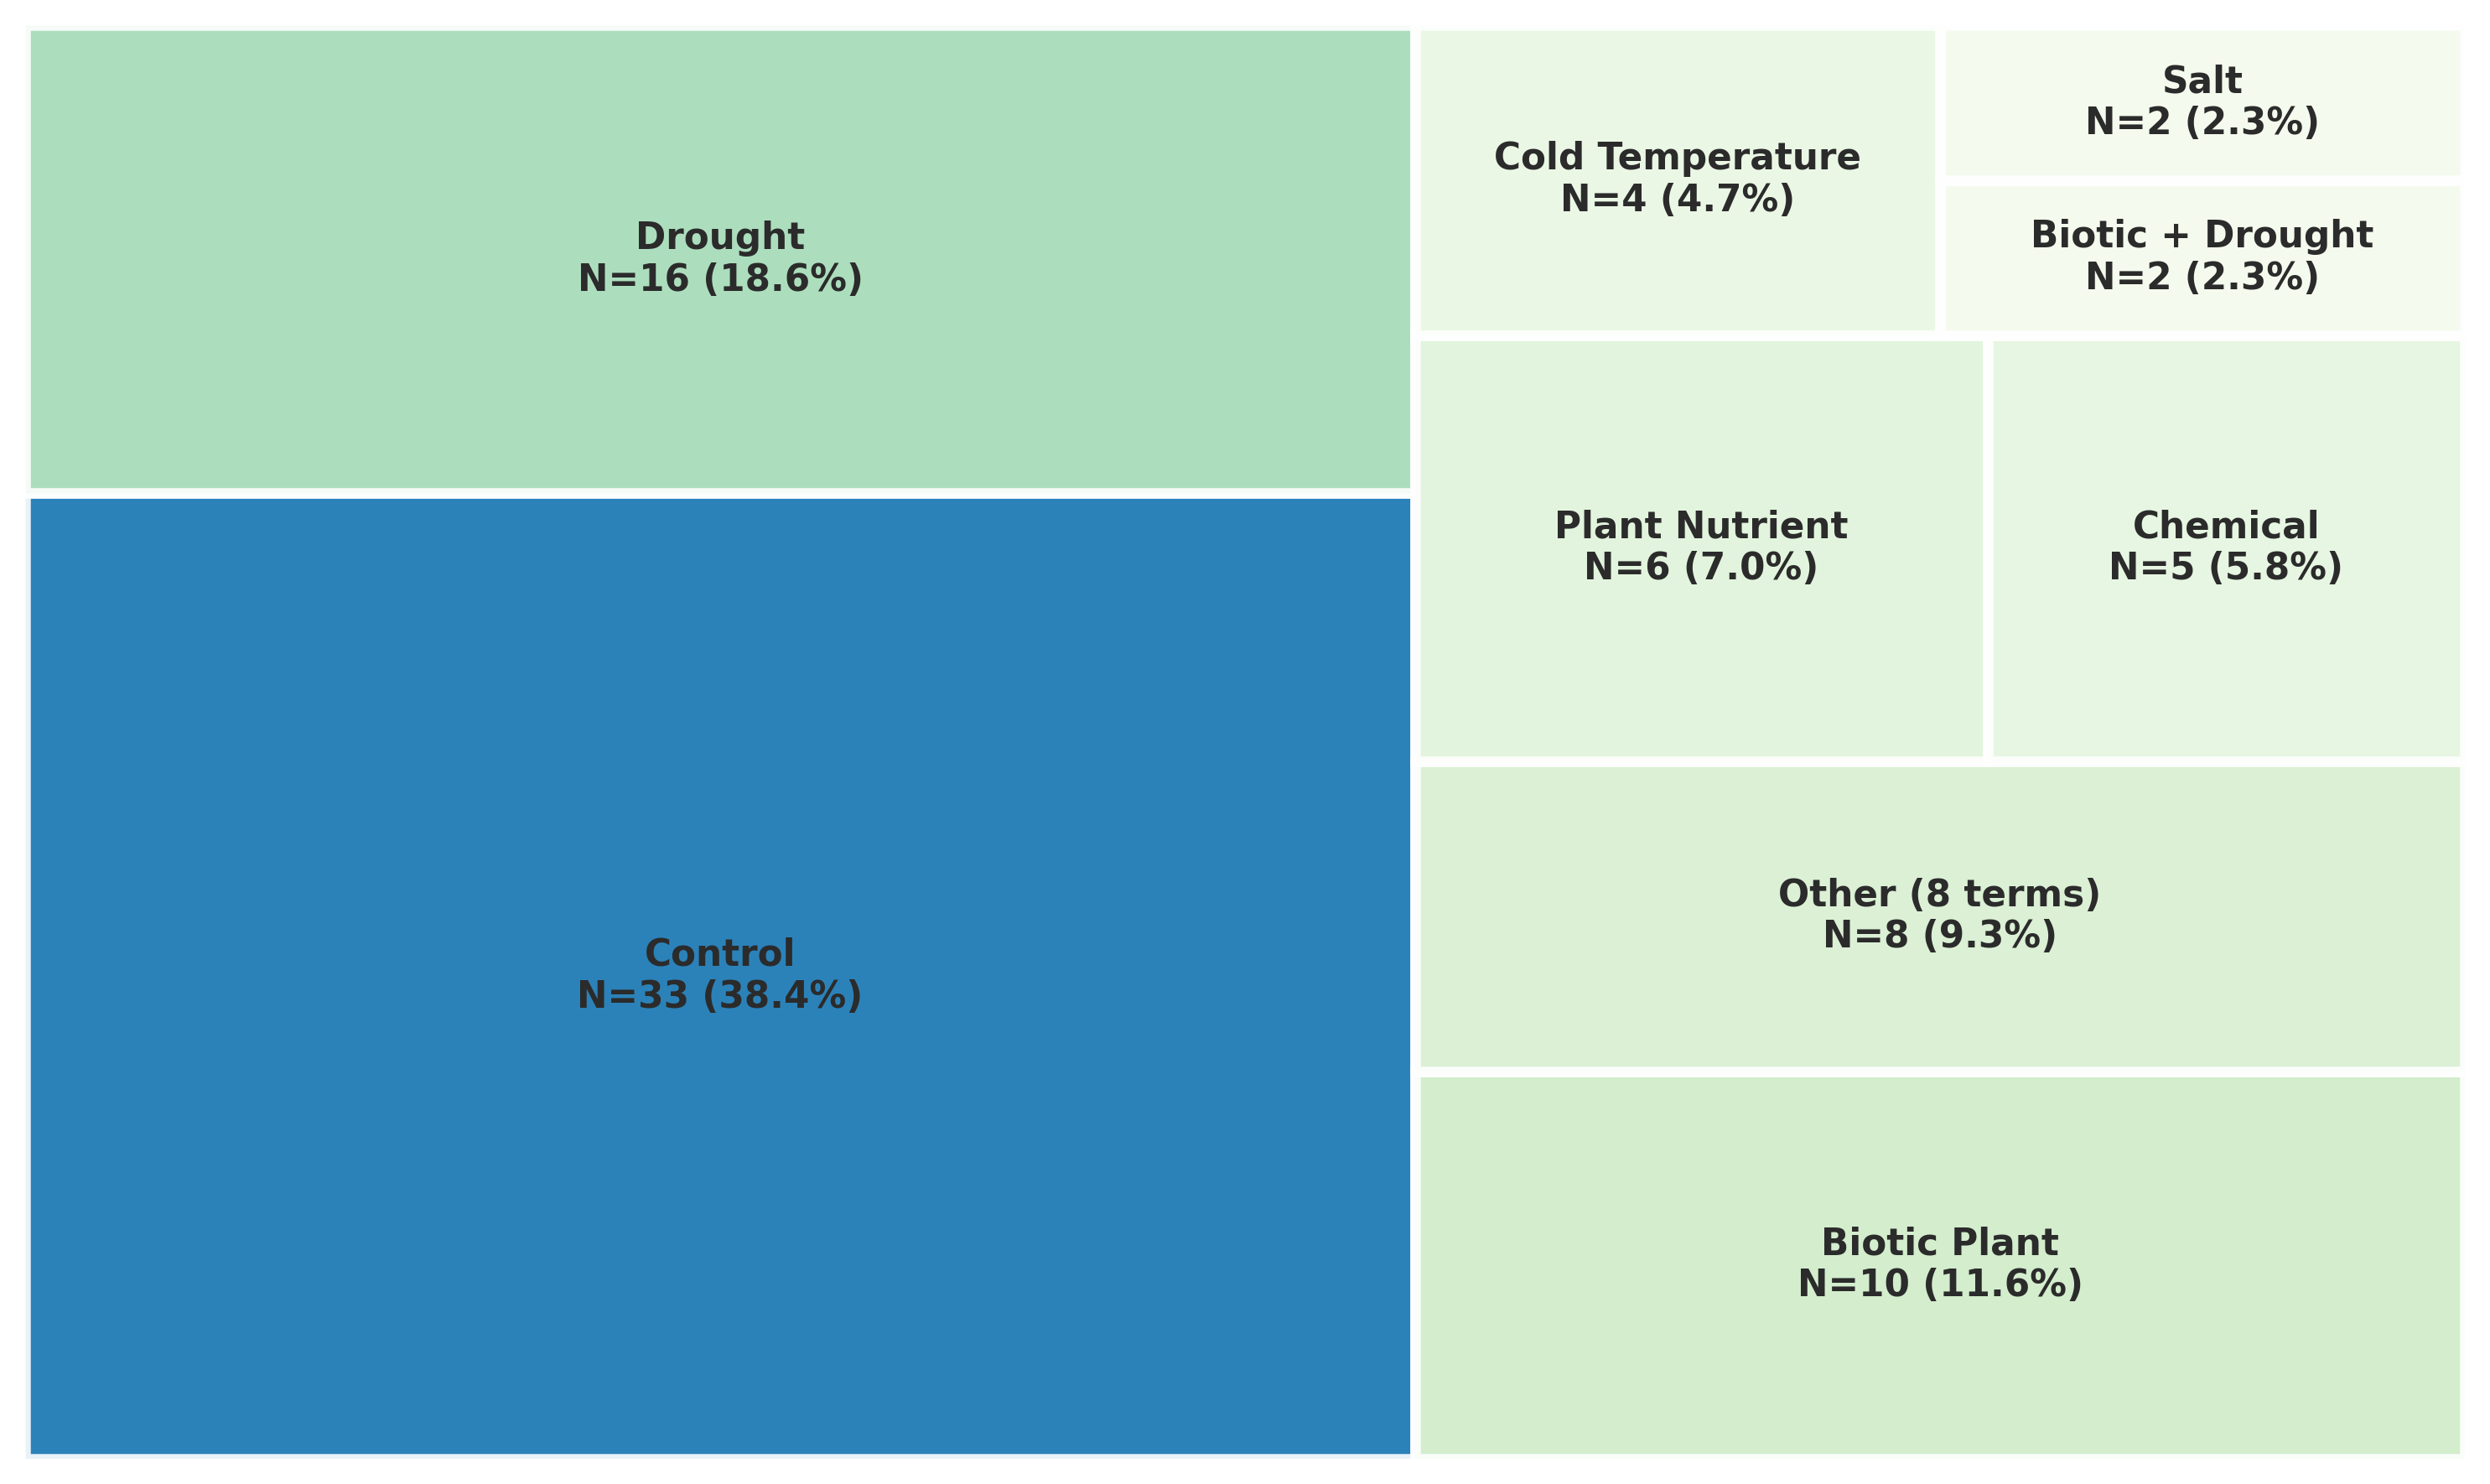

In [20]:
# Map the Plant Ontology IDs to human-readable names
df["ontology_term_treat"] = df["treatment_ontology"].map(peco2name)

# Deduplicate: Count each tissue only once per BioProject
df_unique = df.drop_duplicates(subset=["BioProject", "ontology_term_treat"]).copy()

# Calculate frequencies
term_counts = df_unique["ontology_term_treat"].value_counts().reset_index()
term_counts.columns = ["ontology_term", "count"]

# Grouping minor categories into "Other" if they are below a certain percentage threshold
# Avoid tailoring the plot to a long tail of very small categories that would be hard to read and interpret in a TreeMap
total_count = term_counts["count"].sum()
THRESHOLD_PERCENT = 2.0

# Calculate percentages for all terms to enrich our labels later
term_counts["percentage"] = (term_counts["count"] / total_count) * 100

# Separate major categories and minor categories based on the threshold
major_terms = term_counts[term_counts["percentage"] >= THRESHOLD_PERCENT].copy()
minor_terms = term_counts[term_counts["percentage"] < THRESHOLD_PERCENT].copy()

# If there are minor categories, aggregate them into an "Other" category
if not minor_terms.empty:
    other_count = minor_terms["count"].sum()
    other_percentage = minor_terms["percentage"].sum()
    num_minor_categories = len(minor_terms)

    # Create the aggregated row
    other_row = pd.DataFrame(
        {
            "ontology_term": [f"Other ({num_minor_categories} terms)"],
            "count": [other_count],
            "percentage": [other_percentage],
        }
    )

    # Combine major terms with the new aggregated row
    term_counts_clean = pd.concat([major_terms, other_row], ignore_index=True)
else:
    term_counts_clean = major_terms

# Sort so the largest boxes are positioned first (usually top-left)
term_counts_clean = term_counts_clean.sort_values(by="count", ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Green-Blue colormap colorblind-friendly
cmap = plt.colormaps.get_cmap("GnBu")

# Constrain the normalization range so the darkest color isn't purely dark.
# This ensures our dark gray text remains highly readable on all boxes.
norm = mcolors.Normalize(
    vmin=term_counts_clean["count"].min() * 0.5,
    vmax=term_counts_clean["count"].max() * 1.2,
)
color_list = [cmap(norm(value)) for value in term_counts_clean["count"]]

# Add percentage to the labels for immediate context
labels = [
    f"{row['ontology_term']}\nN={row['count']} ({row['percentage']:.1f}%)"
    for _, row in term_counts_clean.iterrows()
]

# Plot the TreeMap
squarify.plot(
    sizes=term_counts_clean["count"],
    label=labels,
    color=color_list,
    alpha=0.9,  # Slightly less transparent for richer, solid colors
    edgecolor="white",  # Crisp white borders separate the blocks clearly
    linewidth=3,  # Thicker lines create a modern tile effect
    text_kwargs={
        "fontsize": 10.5,
        "fontweight": "bold",
        "color": "#2b2b2b",  # Soft dark gray is more elegant and easier to read than pure black
        "wrap": True,
    },
    ax=ax,
)

# Remove axes for a clean, minimalist look
ax.axis("off")

plt.tight_layout()

plt.show()

# Create Panel

Text(0.0, 60.18, 'N=59\n(37.3%)')

Text(1.0, 52.18, 'N=51\n(32.3%)')

Text(2.0, 2.1799999999999997, 'N=1\n(0.6%)')

Text(0, 0.5, 'Number of Occurrences')

Text(0.5, 0, 'Growth Conditions')

...

(np.float64(0.0), np.float64(100.0), np.float64(0.0), np.float64(100.0))

Text(-0.1, 1.05, 'C')

<Axes: >

(np.float64(0.0), np.float64(100.0), np.float64(0.0), np.float64(100.0))

Text(-0.1, 1.05, 'D')

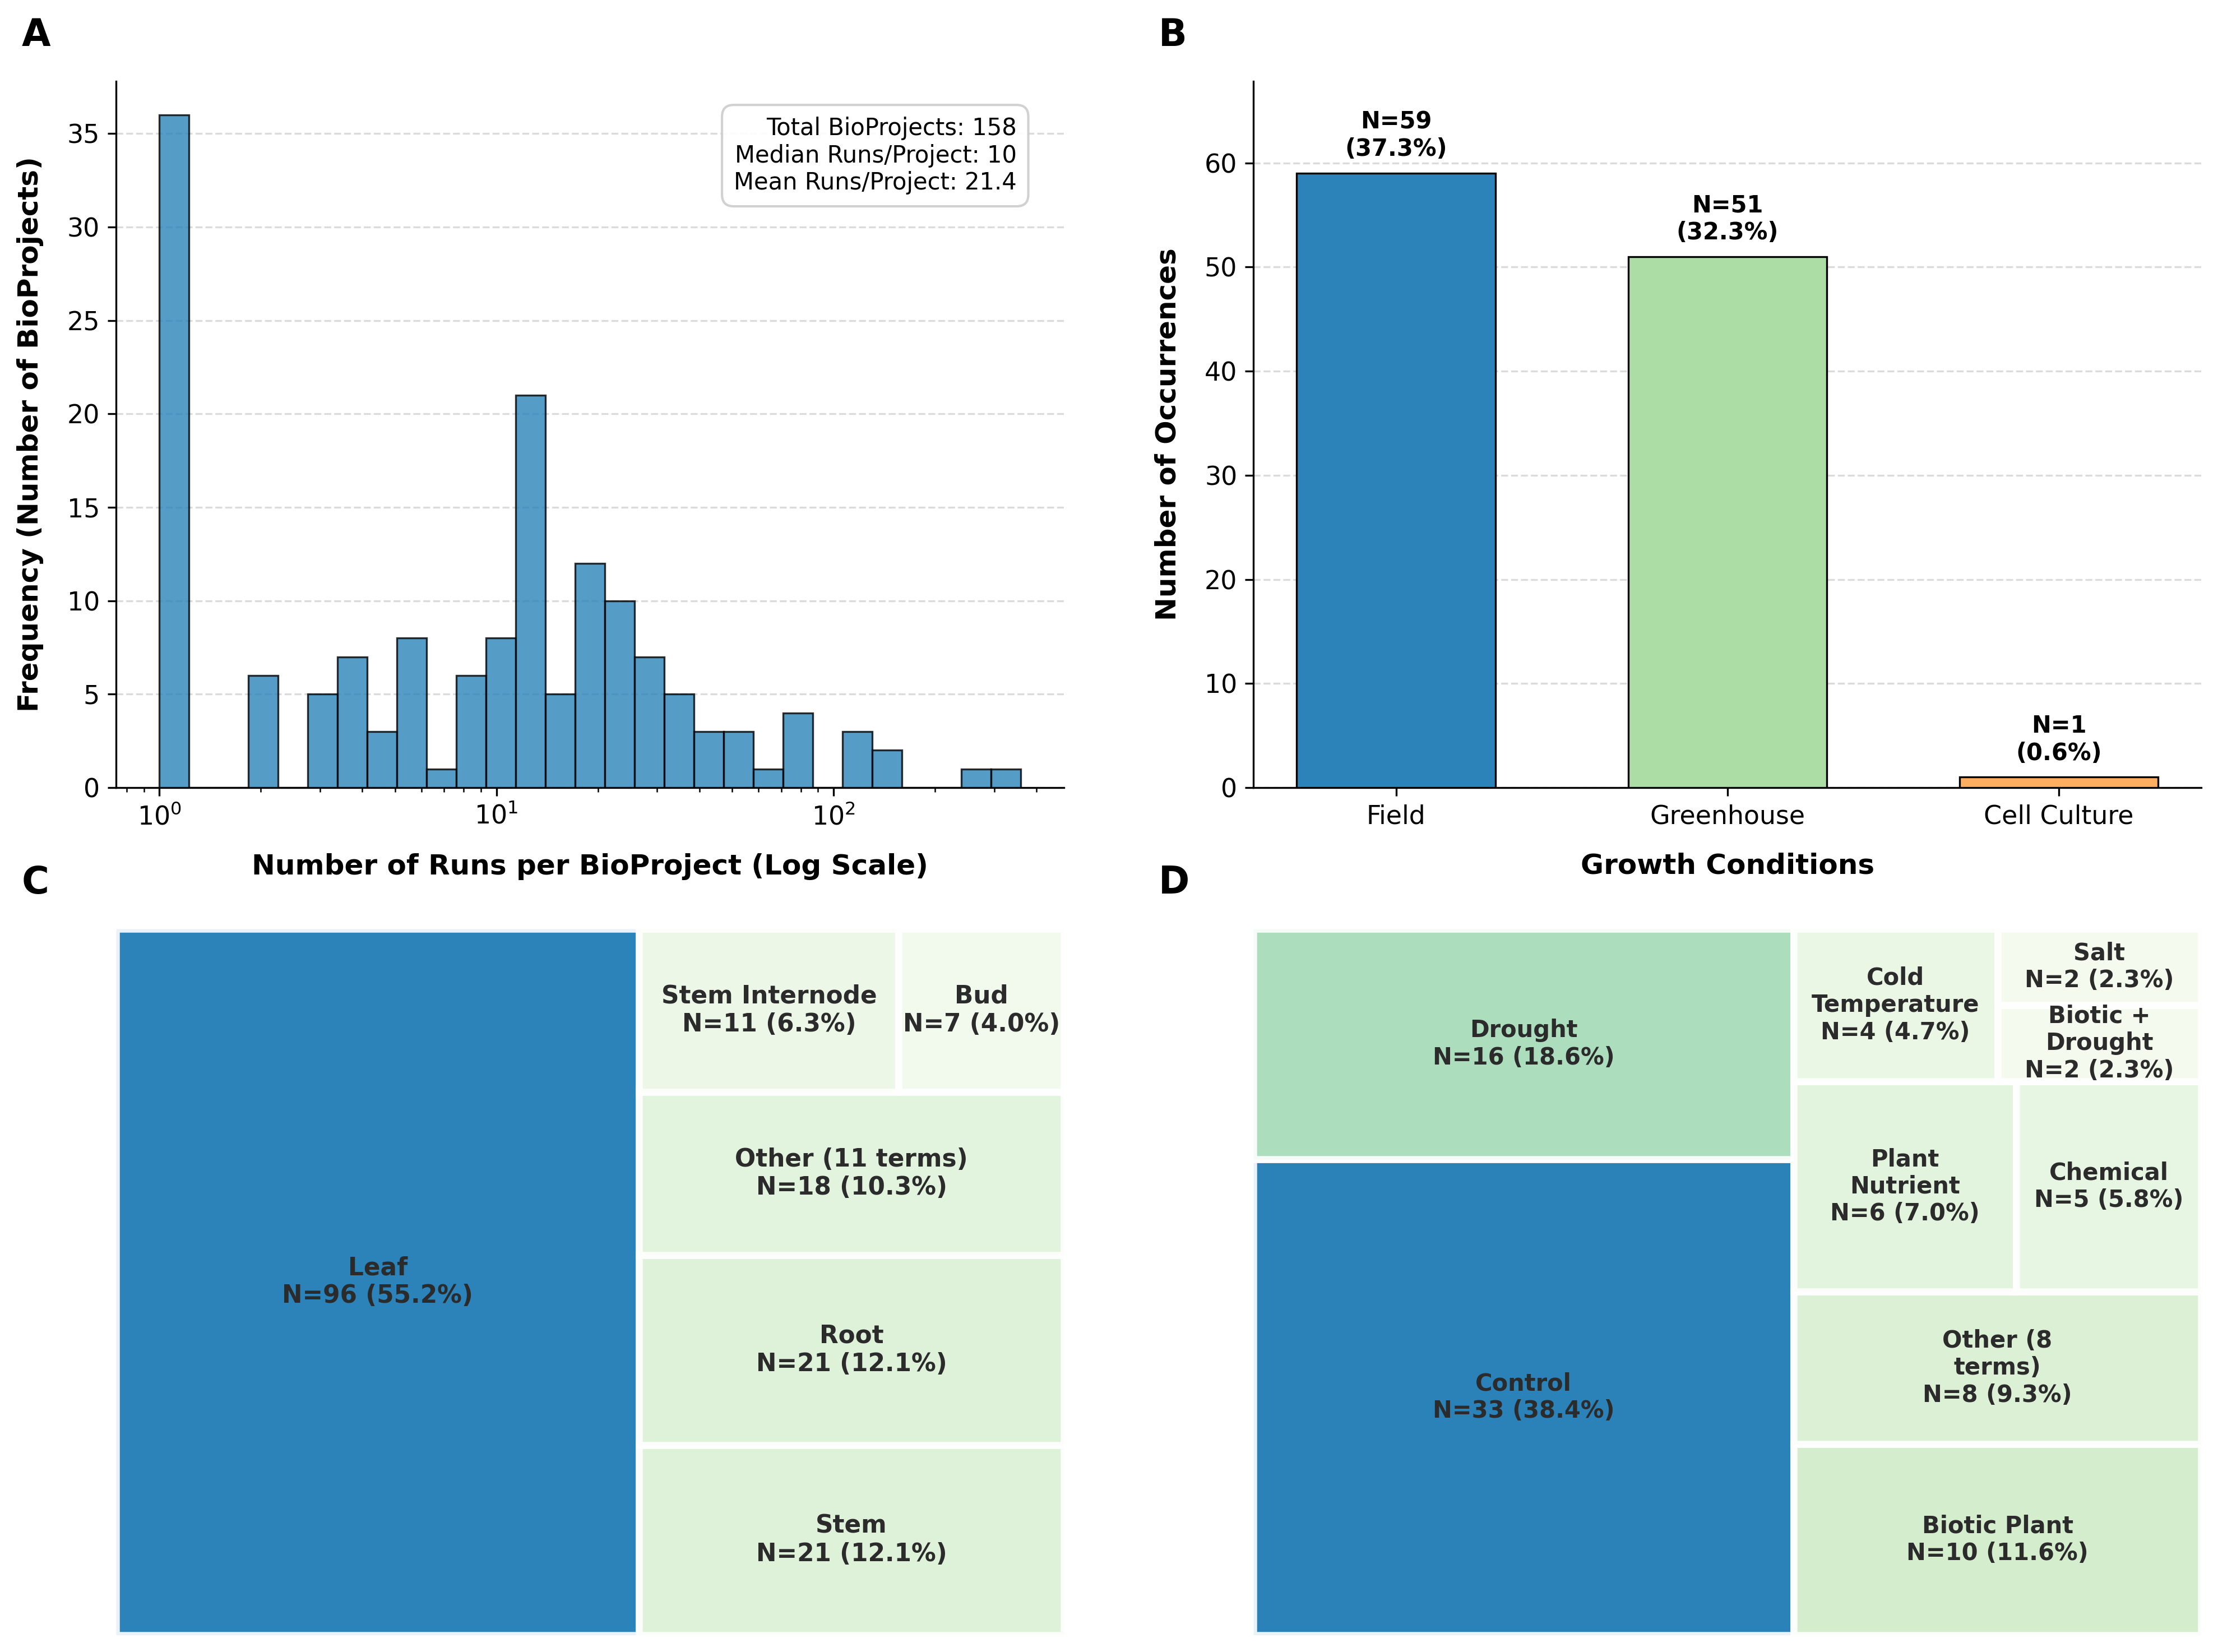

In [21]:
# Put all graphics together
# All graphics are already created in separate cells, so we just need to create a new figure and axes to place them together.
fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=300)

########################################################################################
# Changed the order of the panels to match the typical reading flow (left-to-right, top-to-bottom) and to place the most complex plot (the TreeMap)
# in the bottom-left where it can be easily compared with the simpler bar chart of growth conditions in the top-right.
# Growth Conditions (top-right)
ax_a = axes[0, 1]


# Define a clean, colorblind-friendly color palette for the 3 categories
# Colors: Dark Blue, Light Blue, Orange/Gold
colors = ["#2b83ba", "#abdda4", "#fdae61"]

# Create the bar chart on the specified 'ax_a'
# 'zorder=3' ensures bars are drawn on top of the grid lines
bars = ax_a.bar(
    gc_counts.index,
    gc_counts.values,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    width=0.6,
    zorder=3,
)

# Add exact N and % on top of each bar
for bar, count, pct in zip(bars, gc_counts.values, percentages.values):
    height = bar.get_height()
    # Adding the text slightly above the bar (pad = 2% of the max height)
    ax_a.text(
        bar.get_x() + bar.get_width() / 2,
        height + (gc_counts.max() * 0.02),
        f"N={count}\n({pct:.1f}%)",  # Format: N=value (xx.x%)
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="black",
    )

# Clean up the axes
ax_a.spines["top"].set_visible(False)
ax_a.spines["right"].set_visible(False)

# Add a subtle horizontal grid for better readability of the Y-axis values
ax_a.yaxis.grid(True, linestyle="--", color="#cccccc", alpha=0.7, zorder=0)
ax_a.set_axisbelow(True)  # Ensure grid is strictly behind the bars

# Set labels and title
# but Y-axis labels are mandatory.
ax_a.set_ylabel("Number of Occurrences", fontsize=12, fontweight="bold", labelpad=10)
ax_a.set_xlabel("Growth Conditions", fontsize=12, fontweight="bold", labelpad=10)

# Adjust tick label sizes
ax_a.tick_params(axis="x", labelsize=11)
ax_a.tick_params(axis="y", labelsize=11)

# Ensure Y-axis has enough headroom for the text annotations (expand top limit by 15%)
ax_a.set_ylim(0, gc_counts.max() * 1.15)

# Panel A Label
ax_a.annotate(
    "B", xy=(-0.1, 1.05), xycoords="axes fraction", fontsize=16, fontweight="bold"
)

########################################################################################
# Runs Histogram (top-left)
ax_b = axes[0, 0]

USE_LOG_SCALE = True

# We only want one row per BioProject to understand project size distribution
df_projects = df.drop_duplicates(subset=["BioProject"]).copy()
run_counts = df_projects["RunCount"]

# Conditional logic for Bins and Scale based on the toggle
if USE_LOG_SCALE:
    # Log scale configuration
    min_val = max(1, run_counts.min())  # Avoid log(0)
    max_val = run_counts.max()
    # Create bins that grow logarithmically
    dynamic_bins = np.logspace(np.log10(min_val), np.log10(max_val), num=30)
    ax_b.set_xscale("log")
    x_label = "Number of Runs per BioProject (Log Scale)"
else:
    # Linear scale configuration
    # Create 30 evenly spaced bins from min to max
    dynamic_bins = np.linspace(run_counts.min(), run_counts.max(), num=30)
    # The X-axis defaults to linear
    x_label = "Number of Runs per BioProject (Linear Scale)"

# Create the histogram
counts, bins, patches = ax_b.hist(
    run_counts,
    bins=dynamic_bins,
    color="#2b83ba",  # Professional, colorblind-friendly blue
    edgecolor="black",  # Distinct borders
    linewidth=0.8,
    alpha=0.8,  # Slight transparency
    zorder=3,  # Keep bars above the grid
)

# Clean up spines (remove top and right borders)
ax_b.spines["top"].set_visible(False)
ax_b.spines["right"].set_visible(False)

# Add a subtle grid for the Y-axis
ax_b.yaxis.grid(True, linestyle="--", color="#cccccc", alpha=0.7, zorder=0)
ax_b.set_axisbelow(True)  # Ensure grid is behind the bars

# Set dynamic labels based on the scale chosen
ax_b.set_xlabel(x_label, fontsize=12, fontweight="bold", labelpad=10)
ax_b.set_ylabel(
    "Frequency (Number of BioProjects)", fontsize=12, fontweight="bold", labelpad=10
)

# Tick formatting
ax_b.tick_params(axis="both", which="major", labelsize=11)

# Add a text box with summary statistics
median_runs = run_counts.median()
mean_runs = run_counts.mean()
total_projects = len(run_counts)

stats_text = (
    f"Total BioProjects: {total_projects}\n"
    f"Median Runs/Project: {median_runs:.0f}\n"
    f"Mean Runs/Project: {mean_runs:.1f}"
)

# Place text box in the upper right corner
ax_b.text(
    0.95,
    0.95,
    stats_text,
    transform=ax_b.transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(
        boxstyle="round,pad=0.5", facecolor="white", alpha=0.9, edgecolor="#cccccc"
    ),
)

# Panel B Label
ax_b.annotate(
    "A", xy=(-0.1, 1.05), xycoords="axes fraction", fontsize=16, fontweight="bold"
)

########################################################################################
# Tissue Ontology TreeMap (bottom-left)
ax_c = axes[1, 0]

# Map the Plant Ontology IDs to human-readable names
df["ontology_term"] = df["tissue_ontology"].map(po2name)

# Deduplicate: Count each tissue only ONCE per BioProject
df_unique = df.drop_duplicates(subset=["BioProject", "ontology_term"]).copy()

# Calculate frequencies
term_counts = df_unique["ontology_term"].value_counts().reset_index()
term_counts.columns = ["ontology_term", "count"]

# Grouping minor categories into "Other" if they are below a certain percentage threshold
# Avoid tailoring the plot to a long tail of very small categories that would be hard to read and interpret in a TreeMap
total_count = term_counts["count"].sum()
THRESHOLD_PERCENT = 2.0

# Calculate percentages for all terms to enrich our labels later
term_counts["percentage"] = (term_counts["count"] / total_count) * 100

# Separate major categories and minor categories based on the threshold
major_terms = term_counts[term_counts["percentage"] >= THRESHOLD_PERCENT].copy()
minor_terms = term_counts[term_counts["percentage"] < THRESHOLD_PERCENT].copy()

# If there are minor categories, aggregate them into an "Other" category
if not minor_terms.empty:
    other_count = minor_terms["count"].sum()
    other_percentage = minor_terms["percentage"].sum()
    num_minor_categories = len(minor_terms)

    # Create the aggregated row
    other_row = pd.DataFrame(
        {
            "ontology_term": [f"Other ({num_minor_categories} terms)"],
            "count": [other_count],
            "percentage": [other_percentage],
        }
    )

    # Combine major terms with the new aggregated row
    term_counts_clean = pd.concat([major_terms, other_row], ignore_index=True)
else:
    term_counts_clean = major_terms

# Sort so the largest boxes are positioned first (usually top-left)
term_counts_clean = term_counts_clean.sort_values(by="count", ascending=False)

# Use a softer, professional colormap (Green-Blue).
cmap = plt.colormaps.get_cmap("GnBu")

# Constrain the normalization range so the darkest color isn't purely dark.
# This ensures our dark gray text remains highly readable on all boxes.
norm = mcolors.Normalize(
    vmin=term_counts_clean["count"].min() * 0.5,
    vmax=term_counts_clean["count"].max() * 1.2,
)
color_list = [cmap(norm(value)) for value in term_counts_clean["count"]]

# Add percentage to the labels for immediate context
labels = [
    f"{row['ontology_term']}\nN={row['count']} ({row['percentage']:.1f}%)"
    for _, row in term_counts_clean.iterrows()
]

# Plot the TreeMap
squarify.plot(
    sizes=term_counts_clean["count"],
    label=labels,
    color=color_list,
    alpha=0.9,  # Slightly less transparent for richer, solid colors
    edgecolor="white",  # Crisp white borders separate the blocks clearly
    linewidth=3,  # Thicker lines create a modern tile effect
    text_kwargs={
        "fontsize": 10.5,
        "fontweight": "bold",
        "color": "#2b2b2b",  # Soft dark gray is more elegant and easier to read than pure black
        "wrap": True,
    },
    ax=ax_c,
)

# Remove axes for a clean, minimalist look
ax_c.axis("off")
ax_c.annotate(
    "C", xy=(-0.1, 1.05), xycoords="axes fraction", fontsize=16, fontweight="bold"
)

########################################################################################
# Treatment Ontology TreeMap (bottom-right)
ax_d = axes[1, 1]

# Map the Plant Ontology IDs to human-readable names
df["ontology_term_treat"] = df["treatment_ontology"].map(peco2name)

# Deduplicate: Count each tissue only ONCE per BioProject
df_unique = df.drop_duplicates(subset=["BioProject", "ontology_term_treat"]).copy()

# Calculate frequencies
term_counts = df_unique["ontology_term_treat"].value_counts().reset_index()
term_counts.columns = ["ontology_term", "count"]

# Grouping minor categories into "Other" if they are below a certain percentage threshold
# Avoid tailoring the plot to a long tail of very small categories that would be hard to read and interpret in a TreeMap
total_count = term_counts["count"].sum()
THRESHOLD_PERCENT = 2.0

# Calculate percentages for all terms to enrich our labels later
term_counts["percentage"] = (term_counts["count"] / total_count) * 100

# Separate major categories and minor categories based on the threshold
major_terms = term_counts[term_counts["percentage"] >= THRESHOLD_PERCENT].copy()
minor_terms = term_counts[term_counts["percentage"] < THRESHOLD_PERCENT].copy()

# If there are minor categories, aggregate them into an "Other" category
if not minor_terms.empty:
    other_count = minor_terms["count"].sum()
    other_percentage = minor_terms["percentage"].sum()
    num_minor_categories = len(minor_terms)

    # Create the aggregated row
    other_row = pd.DataFrame(
        {
            "ontology_term": [f"Other ({num_minor_categories} terms)"],
            "count": [other_count],
            "percentage": [other_percentage],
        }
    )

    # Combine major terms with the new aggregated row
    term_counts_clean = pd.concat([major_terms, other_row], ignore_index=True)
else:
    term_counts_clean = major_terms

# Sort so the largest boxes are positioned first (usually top-left)
term_counts_clean = term_counts_clean.sort_values(by="count", ascending=False)

# Green-Blue colormap colorblind-friendly
cmap = plt.colormaps.get_cmap("GnBu")

# Constrain the normalization range so the darkest color isn't purely dark.
# This ensures our dark gray text remains highly readable on all boxes.
norm = mcolors.Normalize(
    vmin=term_counts_clean["count"].min() * 0.5,
    vmax=term_counts_clean["count"].max() * 1.2,
)
color_list = [cmap(norm(value)) for value in term_counts_clean["count"]]

# Add percentage to the labels for immediate context and format the text to fit within the boxes
labels = []
for _, row in term_counts_clean.iterrows():
    # textwrap.fill will automatically insert line breaks to ensure the text fits within the specified width.
    split_name = textwrap.fill(str(row["ontology_term"]), width=12)

    # Combine the split name with the count and percentage, ensuring the entire label is concise and fits well within the box.
    final_name = f"{split_name}\nN={row['count']} ({row['percentage']:.1f}%)"
    labels.append(final_name)

# Plot the TreeMap
squarify.plot(
    sizes=term_counts_clean["count"],
    label=labels,
    color=color_list,
    alpha=0.9,  # Slightly less transparent for richer, solid colors
    edgecolor="white",  # Crisp white borders separate the blocks clearly
    linewidth=3,  # Thicker lines create a modern tile effect
    text_kwargs={
        "fontsize": 10,
        "fontweight": "bold",
        "color": "#2b2b2b",  # Soft dark gray is more elegant and easier to read than pure black
        "wrap": True,
    },
    ax=ax_d,
)

# Remove axes for a clean, minimalist look
ax_d.axis("off")

ax_d.annotate(
    "D", xy=(-0.1, 1.05), xycoords="axes fraction", fontsize=16, fontweight="bold"
)

plt.savefig("figure_panel.png", bbox_inches="tight", dpi=300)